In [8]:
%pip install networkx scipy # numba matplotlib numpy pandas seaborn tqdm joblib

  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
Using cached networkx-3.5-py3-none-any.whl (2.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ==== LaTeX + SVG text mode (Illustrator-safe) ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18      # x/y labels
plt.rcParams['axes.titlesize'] = 20 
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12     # legend text


In [7]:
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
hist_color = "#d9d9d9" 

In [2]:
path_to_data = "/home/keerthm/twinfer/supp_figure/"
path_to_plots = "/home/keerthm/twinfer/plots/"
path_to_code_repo = "/home/keerthm/twinfer/TwINFER/"

## Effect of varying Hill constant

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os
from tqdm.auto import tqdm
import re
from pathlib import Path
import glob

/home/keerthm/twinfer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def extract_k_values(simulation_folder):
    """
    Extract k values from filenames in the simulation folder.
    
    Args:
        simulation_folder (str): Path to the folder containing simulation files
    
    Returns:
        list: List of tuples containing (filename, k_value)
    """
    
    # Check if folder exists
    if not os.path.exists(simulation_folder):
        print(f"Error: Folder {simulation_folder} does not exist")
        return []
    
    # Pattern to match scale_k_ followed by a number (including decimal)
    k_pattern = r'scale_k_([0-9]*\.?[0-9]+)'
    
    k_values = []
    
    # Iterate through all files in the folder
    for filename in os.listdir(simulation_folder):
        # Only process CSV files (or remove this filter if you want all files)
        if filename.endswith('.csv') and filename.startswith('df') and "rep" in filename:
            # Search for the k value pattern in the filename
            match = re.search(k_pattern, filename)
            if match:
                k_value = float(match.group(1))  # Extract and convert to float
                k_values.append((filename, k_value))
            else:
                print(f"Warning: No k value found in filename: {filename}")
    
    return k_values

def print_k_values(k_values):
    """Print the extracted k values in a formatted way"""
    if not k_values:
        print("No k values found.")
        return
    
    print(f"Found {len(k_values)} files with k values:")
    print("-" * 80)
    print(f"{'Filename':<60} {'K Value':<10}")
    print("-" * 80)
    
    # Sort by k value for better readability
    k_values_sorted = sorted(k_values, key=lambda x: x[1])
    
    for filename, k_value in k_values_sorted:
        print(f"{filename:<60} {k_value:<10}")

def get_unique_k_values(k_values):
    """Get unique k values"""
    unique_k = sorted(list(set([k for _, k in k_values])))
    return unique_k


In [3]:
def process_simulation(df_path, k, t1=1, t2=20, gene_list=['gene_1', 'gene_2']): 
    sim_data = {} 
    df = pd.read_csv(df_path) 
    expression_t1 = df[df['time_step'] == t1] 
    expression_t2 = df[df['time_step'] == t2] 
    sim_data["k"] = k 
    for gene in gene_list: 
        # Mean 
        sim_data[f"mean_{gene}_t1"] = expression_t1[f"{gene}_mRNA"].mean() 
        sim_data[f"mean_{gene}_t2"] = expression_t2[f"{gene}_mRNA"].mean() 
        # Variance 
        sim_data[f"var_{gene}_t1"] = expression_t1[f"{gene}_mRNA"].var() 
        sim_data[f"var_{gene}_t2"] = expression_t2[f"{gene}_mRNA"].var() 
        
        # Spearman correlations 
    sim_data["corr_t1"], _ = spearmanr( expression_t1[f"{gene_list[0]}_mRNA"], expression_t1[f"{gene_list[1]}_mRNA"] ) 
    sim_data["corr_t2"], _ = spearmanr( expression_t2[f"{gene_list[0]}_mRNA"], expression_t2[f"{gene_list[1]}_mRNA"] ) 
    return sim_data

In [88]:

# Main execution
if __name__ == "__main__":
    simulation_folder = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/hill_constant_effect/simulations/"
    k_values = extract_k_values(simulation_folder)
    
    # Optional: Create a dictionary mapping k values to filenames
    k_to_files = {}
    for filename, k_value in k_values:
        if k_value not in k_to_files:
            k_to_files[k_value] = []
        k_to_files[k_value].append(filename)
    

In [90]:
data = []
for k, paths in k_to_files.items():
    for path in paths:   # loop over ALL replicates
        full_path = f"{simulation_folder}/{path}"
        sim_data = process_simulation(full_path, k)
        sim_data["rep_file"] = path   # optional: keep track of replicate filename
        data.append(sim_data)

results = pd.DataFrame(data)
results.sort_values("k", axis=0, ascending=True, inplace=True)
results = results.reset_index(drop=True)


In [ ]:
# Aggregate over replicates
agg = (
    results.groupby("k")[["corr_t1", "corr_t2"]]
    .agg(["mean", "std"])
)

# flatten multiindex columns
agg.columns = ["_".join(col) for col in agg.columns]
agg = agg.reset_index()

# Plot
plt.figure(figsize=(7,5))

for corr in ["t1"]:
    mean = agg[f"corr_{corr}_mean"]
    std  = agg[f"corr_{corr}_std"]
    
    # mean line
    plt.plot(agg["k"], mean, marker = "o")
    # shaded std
    plt.fill_between(
        agg["k"], mean - std, mean + std, alpha=0.3
    )

# reference lines
plt.axvline(x=1, linestyle="--", color="red")
plt.axhline(y=0.0, linestyle="--", color="gray")

# Turn off clipping globally
for artist in plt.gcf().findobj():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# labels
plt.xlabel(r'$\frac{\text{K}}{\langle \text{TF} \rangle}$', size = 20)
plt.ylabel(r'gene correlation ($\rho$)', size = 20)
plt.tight_layout()

plt.savefig(
    "/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/effect_Hill_constant.svg",
    format="svg",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    "/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/effect_Hill_constant.png",
    format="png",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)

plt.show()


## Effect of $k_{add}$

In [ ]:
from joblib import Parallel, delayed
import pandas as pd
import os, glob, re
from tqdm.auto import tqdm

sim_folder = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/k_add_simulations/A_to_B_reps/"
details_file = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/k_add_simulations/simulation_details/effect_of_k_add_sampling_positive_with_reps.csv"

# Load parameter details with explicit param_row
details_df = pd.read_csv(details_file).reset_index().rename(columns={"index": "param_row"})

pattern = re.compile(r"df_row_(\d+)_(\d+)_")

def process_file(filepath, details_df):
    fname = os.path.basename(filepath)
    if fname.startswith("sim"):
        return None

    # Extract param_row
    m = pattern.search(fname)
    if not m:
        return None
    _, param_row = int(m.group(1)), int(m.group(2))

    # Lookup k_add
    row = details_df[details_df["param_row"] == param_row]
    if row.empty:
        return None
    r = row.iloc[0]
    k = r["k_add_gene_1_to_gene_2"]
    k_off = r["k_off"]

    # Run analysis (assuming this returns a dict or DataFrame with correlation values)
    sim_data = process_simulation(filepath, k)
    sim_data['k_add'] = k
    sim_data['k_off'] = k_off

    return  sim_data



# Get all files
all_files = glob.glob(os.path.join(sim_folder, "*.csv"))

# Parallel loop
results = Parallel(n_jobs=-8)(  # use all available cores
    delayed(process_file)(filepath, details_df) for filepath in tqdm(all_files)
)

# Filter out None results
results = [r for r in results if r is not None]

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values("k_add", axis=0, ascending=True, inplace=True)
results_df.reset_index(drop=True, inplace=True)

results_df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/k_add_activation.csv")


In [63]:
results_df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/k_add_activation.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
results_df = pd.read_csv('/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/k_add_activation.csv')
# Group by both k_add and k_off
agg_df = (
    results_df.groupby(["k_add", "k_off"])["corr_t1"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# --- find which k_off is closest to 8.76 ---
closest_koff = agg_df["k_off"].iloc[(agg_df["k_off"] - 8.76).abs().argmin()]
print(f"Closest k_off to 8.76: {closest_koff}")

# Plot
fig, ax = plt.subplots(figsize=(7,5))

# Normalize k_off for colormap
koffs = agg_df["k_off"].unique()
norm = plt.Normalize(min(koffs), max(koffs))
cmap = plt.cm.Blues_r  

# Truncate to avoid very light colors (e.g. use only 0.2–1.0 of the range)
def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap
# --- Truncate colormap to avoid washed-out light colors ---
cmap_trunc = truncate_colormap(cmap, 0, 0.7)  # only use darker range

for k_off_val, subdf in agg_df.groupby("k_off"):
    color = cmap_trunc(norm(k_off_val))  # consistent color for both line & fill
    x = subdf["k_add"].values / 0.66
    y = subdf["mean"].values
    yerr = subdf["std"].values

    lw = 5 if k_off_val == closest_koff else 1.5  # bold highlight line
    ls = "-" if k_off_val == closest_koff else "--"  # bold highlight line
    # Mean line
    ax.plot(x, y, marker = "o", color=color, lw=lw, alpha=1.0, linestyle = ls, markersize=3)

    # Fill band with same color but transparent
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.1)


# reference lines
ax.axhline(y=0.0, linestyle="--", color="gray")




ax.axvline(x=6.0/0.66, linestyle="--", color="red")

# labels
ax.set_xlabel(r"$\frac{\text{k}_{\text{add}}^{\text{max}}}{\text{k}_{\text{on}}}$", size = 20)
ax.set_ylabel(r"gene correlation ($\rho$)", size = 20)
for artist in plt.gcf().findobj():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# add colorbar
plt.xscale('log')
sm = plt.cm.ScalarMappable(cmap=cmap_trunc, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\text{k}_{\text{off}}$", size = 20)
# plt.xscale('log')
plt.tight_layout()


plt.savefig(
    "/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/k_add_activation.svg",
    format="svg",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    "/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/k_add_activation.png",
    format="png",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.show()


In [ ]:
# ---- Main loop ----
sim_folder = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/k_add_simulations/A_rep_B_with_reps/"
details_file = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/k_add_simulations/simulation_details/effect_of_k_add_sampling_repression_with_reps.csv"

# Load parameter details with explicit param_row
details_df = pd.read_csv(details_file).reset_index().rename(columns={"index": "param_row"})

from joblib import Parallel, delayed
import pandas as pd
import os, glob, re
from tqdm.auto import tqdm


pattern = re.compile(r"df_row_(\d+)_(\d+)_")

def process_file(filepath, details_df):
    fname = os.path.basename(filepath)
    if fname.startswith("sim"):
        return None

    # Extract param_row
    m = pattern.search(fname)
    if not m:
        return None
    _, param_row = int(m.group(1)), int(m.group(2))

    # Lookup k_add
    row = details_df[details_df["param_row"] == param_row]
    if row.empty:
        return None
    r = row.iloc[0]
    k = r["k_add_gene_1_to_gene_2"]
    k_off = r["k_off"]

    # Run analysis (assuming this returns a dict or DataFrame with correlation values)
    sim_data = process_simulation(filepath, k)
    sim_data['k_add'] = k
    sim_data['k_off'] = k_off

    return  sim_data



# Get all files
print(sim_folder)
all_files = glob.glob(os.path.join(sim_folder, "df*.csv"))

# Parallel loop
results = Parallel(n_jobs=8)(  # use all available cores
    delayed(process_file)(filepath, details_df) for filepath in tqdm(all_files)
)

# Filter out None results
results = [r for r in results if r is not None]

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values("k_add", axis=0, ascending=True, inplace=True)
results_df.reset_index(drop=True, inplace=True)


In [72]:
results_df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/k_add_repression.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
results_df = pd.read_csv('/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/k_add_repression.csv')
# Group by both k_add and k_off
agg_df = (
    results_df.groupby(["k_add", "k_off"])["corr_t1"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# --- find which k_off is closest to 8.76 ---
closest_koff = agg_df["k_off"].iloc[(agg_df["k_off"] - 8.76).abs().argmin()]
print(f"Closest k_off to 8.76: {closest_koff}")

# Plot
fig, ax = plt.subplots(figsize=(7,5))

# Normalize k_off for colormap
koffs = agg_df["k_off"].unique()
norm = plt.Normalize(min(koffs), max(koffs))
cmap = plt.cm.Blues_r  

# Truncate to avoid very light colors (e.g. use only 0.2–1.0 of the range)
def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

cmap_trunc = truncate_colormap(cmap, 0, 0.7)

for k_off_val, subdf in agg_df.groupby("k_off"):
    color = cmap_trunc(norm(k_off_val))
    x = subdf["k_add"].values/0.66
    y = subdf["mean"].values
    yerr = subdf["std"].values

    # Make line thicker if this is the closest k_off
    lw = 5 if k_off_val == closest_koff else 1.5
    ls = "-" if k_off_val == closest_koff else "--"
    alpha = 1.0 

    # Plot mean line
    ax.plot(x, y, "o", color=color, linestyle = ls,  lw=lw, alpha=alpha, markersize=3)

    # Fill between mean ± std
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.1)

# reference lines
ax.axhline(y=0.0, linestyle="--", color="gray")
ax.axvline(x=1.0/0.66, linestyle="--", color="red")

# labels
ax.set_xlabel(r"$\frac{\text{k}_{\text{add}}^{\text{max}}}{\text{k}_{\text{on}}}$", size = 20)
ax.set_ylabel(r"gene correlation ($\rho$)", size = 20)

# add colorbar

for artist in plt.gcf().findobj():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

sm = plt.cm.ScalarMappable(cmap=cmap_trunc, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\text{k}_{\text{off}}$", size = 20)


plt.savefig(
    "/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/k_add_repression.svg",
    format="svg",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    "/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/k_add_repression.png",
    format="png",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)

plt.tight_layout()
plt.show()


## Twin correlation over time

In [2]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import importlib
import matplotlib.pyplot as plt
from numba import set_num_threads, get_num_threads


sys.path.append(str(path_to_code_repo))

from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)

from TwINFER_function_scripts.correlation_analysis_functions import (
    
    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data, 
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

/home/keerthm/twinfer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


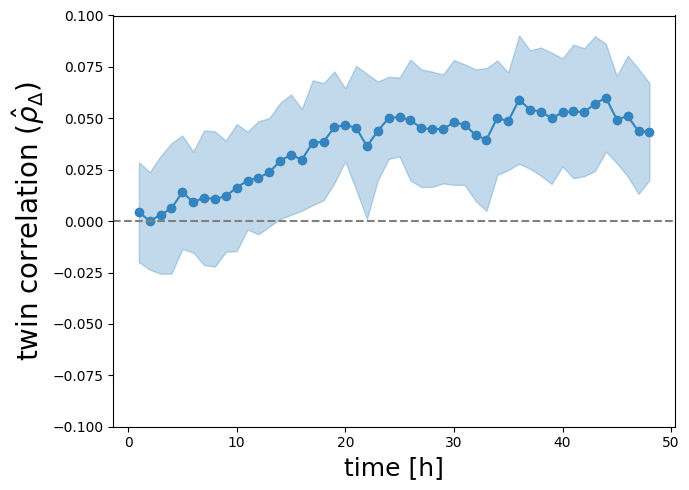

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# # # Paths
# folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_to_B/")
# path_to_connectivity_matrix = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_parameter_simulations/figure_2_simulation_details/interaction_matrix_A_to_B.txt"

# # Read interaction matrix and set up gene list
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# # Parameters
# seed = 1010
# np.random.seed(seed)

# results = []

# # Loop over all CSVs in folder
# for csv_path in folder.glob("df_rows_*.csv"):
#     simulation = pd.read_csv(csv_path)
#     n_clones_simulation = simulation['clone_id'].nunique()
    
#     # Shuffle clones
#     clone_ids_shuffled = np.random.permutation(n_clones_simulation)
#     n1 = n2 = n_clones_simulation // 4
#     t1_clones = clone_ids_shuffled[:n1]
#     t2_clones = clone_ids_shuffled[n1:n1 + n2]
#     across_t_clones = clone_ids_shuffled[n1 + n2:]
    
#     t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

#     # Across_t: pick exactly one random twin per clone_id
#     # One cell per clone at t1
#     across_t_twin1 = (
#         simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
#     )
    
#     across_t_twin2 = (
#         simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
#     )

#     # Reset index for cleanliness
#     t1_twins = t1_twins.reset_index(drop=True)
#     t2_twins = t2_twins.reset_index(drop=True)
#     across_t_twin1 = across_t_twin1.reset_index(drop=True)
#     across_t_twin2 = across_t_twin2.reset_index(drop=True)

#     all_t1_t2_measurements = pd.concat(
#     [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
#     ignore_index=True
#     )

#     # Loop across all time points available
#     for t1 in sorted(simulation['time_step'].unique()):
#         # Twins at this time
#         t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)]
#         t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

#         # Across_t: pick exactly one random twin per clone_id
#         # One cell per clone at t1
#         across_t_twin1 = (
#             simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
#         )
        
#         across_t_twin2 = (
#             simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
#         )

#         # Reset index for cleanliness
#         t1_twins = t1_twins.reset_index(drop=True)
#         t2_twins = t2_twins.reset_index(drop=True)
#         across_t_twin1 = across_t_twin1.reset_index(drop=True)
#         across_t_twin2 = across_t_twin2.reset_index(drop=True)

#         all_t1_t2_measurements = pd.concat(
#         [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
#         ignore_index=True
#         )
#         if t1_twins.empty:
#             continue
        
#         # Pairwise gene–gene correlation matrix
#         twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#         )
        
#         # Twin correlation (example: gene_1 vs gene_2)
#         twin_corr = twin_pair_correlation_matrix_t1.loc['gene_1', 'gene_2']
        
#         results.append({
#             "file": csv_path.name,
#             "time_step": t,
#             "twin_corr_gene1_gene2": twin_corr
#         })

# # Collect into DataFrame
# results_df = pd.DataFrame(results)
# results_df = results_df.sort_values(by=["file", "time_step"]).reset_index(drop=True)

# # Save table (optional)
# results_df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/twin_correlation_over_time_A_to_B.csv", index=False)
# folder_name = "A_to_B"
results_df = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/twin_correlation_over_time_A_to_B.csv")
# Aggregate over replicates (if multiple CSVs per time_step)
agg = (
    results_df.groupby("time_step")[["twin_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)

# Flatten multiindex columns
agg.columns = ["_".join(col) for col in agg.columns]
agg = agg.reset_index()

# Plot
plt.figure(figsize=(7, 5))

mean = agg["twin_corr_gene1_gene2_mean"]
std = agg["twin_corr_gene1_gene2_std"]

import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'   # keep text as text in SVG

# Mean line
line, = plt.plot(agg["time_step"], mean, marker="o", color="#3484BF")
line.set_clip_on(False)

# Shaded std
poly = plt.fill_between(
    agg["time_step"], mean - std, mean + std, alpha=0.3, color="#3484BF"
)
poly.set_clip_on(False)

# Reference line
ref = plt.axhline(y=0.0, linestyle="--", color="gray")
ref.set_clip_on(False)

# Labels
xlabel = plt.xlabel("time [h]", size=18)
ylabel = plt.ylabel(r"twin correlation ($\hat{\rho}_{\Delta}$)", size=20)
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)

# Limits and layout
plt.ylim(-0.1, 0.1)
plt.tight_layout()

# Disable clipping for everything else in the axes (ticks, spines, etc.)
ax = plt.gca()
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

# Save clean (no clip paths, text remains as text)
plt.savefig(
    f"/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/twin_correlation_over_time_{folder_name}.svg",
    format="svg",
    facecolor="none",
    transparent=True
)
plt.savefig(
    f"/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/twin_correlation_over_time_{folder_name}.png",
    format="png",
    facecolor="none",
    transparent=True
)

plt.show()



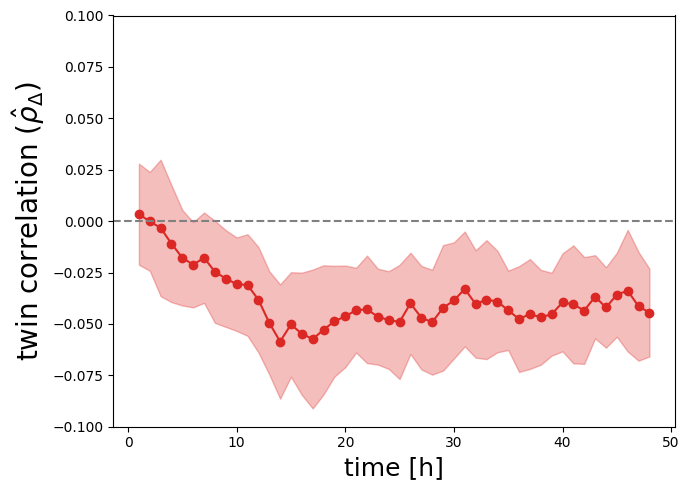

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
folder_name = "A_rep_B"
# folder = Path(f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_parameter_simulations/figure_3_simulations/{folder_name}/")
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_parameter_simulations/figure_2_simulation_details/interaction_matrix_{folder_name}.txt"

# # Read interaction matrix and set up gene list
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# # Parameters
# seed = 1010
# np.random.seed(seed)

# results = []

# # Loop over all CSVs in folder
# for csv_path in folder.glob("df_rows_*.csv"):
#     simulation = pd.read_csv(csv_path)
#     n_clones_simulation = simulation['clone_id'].nunique()
    
#     # Shuffle clones
#     clone_ids_shuffled = np.random.permutation(n_clones_simulation)
#     n1 = n2 = n_clones_simulation // 4
#     t1_clones = clone_ids_shuffled[:n1]
#     t2_clones = clone_ids_shuffled[n1:n1 + n2]
#     across_t_clones = clone_ids_shuffled[n1 + n2:]
    
#     t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

#     # Across_t: pick exactly one random twin per clone_id
#     # One cell per clone at t1
#     across_t_twin1 = (
#         simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
#     )
    
#     across_t_twin2 = (
#         simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
#     )

#     # Reset index for cleanliness
#     t1_twins = t1_twins.reset_index(drop=True)
#     t2_twins = t2_twins.reset_index(drop=True)
#     across_t_twin1 = across_t_twin1.reset_index(drop=True)
#     across_t_twin2 = across_t_twin2.reset_index(drop=True)

#     all_t1_t2_measurements = pd.concat(
#     [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
#     ignore_index=True
#     )

#     # Loop across all time points available
#     for t in sorted(simulation['time_step'].unique()):
#         # Twins at this time
#         t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t)]
        
#         if twins.empty:
#             continue
        
#         # Pairwise gene–gene correlation matrix
#         twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#         )
        
#         # Twin correlation (example: gene_1 vs gene_2)
#         twin_corr = twin_pair_correlation_matrix_t1.loc['gene_1', 'gene_2']
        
#         results.append({
#             "file": csv_path.name,
#             "time_step": t,
#             "twin_corr_gene1_gene2": twin_corr
#         })

# # Collect into DataFrame
# results_df = pd.DataFrame(results)
# results_df = results_df.sort_values(by=["file", "time_step"]).reset_index(drop=True)

# # Save table (optional)
# results_df.to_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/twin_correlation_over_time_{folder_name}.csv", index=False)

results_df = pd.read_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/twin_correlation_over_time_{folder_name}.csv")
# Aggregate over replicates (if multiple CSVs per time_step)
agg = (
    results_df.groupby("time_step")[["twin_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)

# Flatten multiindex columns
agg.columns = ["_".join(col) for col in agg.columns]
agg = agg.reset_index()

# Plot
plt.figure(figsize=(7, 5))

mean = agg["twin_corr_gene1_gene2_mean"]
std = agg["twin_corr_gene1_gene2_std"]

import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'   # keep text as text in SVG

# Mean line
line, = plt.plot(agg["time_step"], mean, marker="o", color="#DB2824")
line.set_clip_on(False)

# Shaded std
poly = plt.fill_between(
    agg["time_step"], mean - std, mean + std, alpha=0.3, color="#DB2824"
)
poly.set_clip_on(False)

# Reference line
ref = plt.axhline(y=0.0, linestyle="--", color="gray")
ref.set_clip_on(False)

# Labels
xlabel = plt.xlabel("time [h]", size=18)
ylabel = plt.ylabel(r"twin correlation ($\hat{\rho}_{\Delta}$)", size=20)
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)

# Limits and layout
plt.ylim(-0.1, 0.1)
plt.tight_layout()

# Disable clipping for everything else in the axes (ticks, spines, etc.)
ax = plt.gca()
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

# Save clean (no clip paths, text remains as text)
plt.savefig(
    f"/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/twin_correlation_over_time_{folder_name}.svg",
    format="svg",
    facecolor="none",
    transparent=True
)
plt.savefig(
    f"/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/twin_correlation_over_time_{folder_name}.png",
    format="png",
    facecolor="none",
    transparent=True
)

plt.show()



### 2 states correlation over time - both twin and random

In [10]:
def split_and_merge_simulations(path_to_simulation_files):
    simulation_1 = pd.read_csv(path_to_simulation_files[0])
    simulation_2 = pd.read_csv(path_to_simulation_files[1])
    clone_ids = sorted(simulation_1['clone_id'].unique())
    half_point = len(clone_ids) // 2
    clones_from_sim1 = clone_ids[:half_point]
    clones_from_sim2 = clone_ids[half_point:]
    sim1_subset = simulation_1[simulation_1['clone_id'].isin(clones_from_sim1)]
    sim2_subset = simulation_2[simulation_2['clone_id'].isin(clones_from_sim2)]
    return pd.concat([sim1_subset, sim2_subset], ignore_index=True)

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
t1 = 1
t2 = 20
# Paths
folder_name = "A_B_2_states"
low_folder  = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_low_k_on")
high_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_high_k_on")

low_csvs  = sorted(low_folder.glob("df_rows_*.csv"))
high_csvs = sorted(high_folder.glob("df_rows_*.csv"))

path_to_connectivity_matrix = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/connectivity_matrix_A_B.txt"
n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]
results = []
# Parameters
seed = 1010


rng = np.random.default_rng(seed)

# --- match by replicate number ---
def get_rep_number(path):
    # extract final "rep_X" from filename
    return int(path.stem.split("_rep_")[-1])

# dictionary: rep → path
low_by_rep  = {get_rep_number(p): p for p in low_csvs}
high_by_rep = {get_rep_number(p): p for p in high_csvs}

# process only reps present in BOTH
common_reps = sorted(set(low_by_rep) & set(high_by_rep))

for rep in common_reps:
    pair_paths = [low_by_rep[rep], high_by_rep[rep]]
    
    # --- 1. split + merge ---
    simulation = split_and_merge_simulations(pair_paths)
    n_clones_simulation = simulation['clone_id'].nunique()
    
    # Shuffle clones
    clone_ids_shuffled = np.random.permutation(n_clones_simulation)
    n1 = n2 = n_clones_simulation // 4
    t1_clones = clone_ids_shuffled[:n1]
    t2_clones = clone_ids_shuffled[n1:n1 + n2]
    across_t_clones = clone_ids_shuffled[n1 + n2:]
    
    t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]
    t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

    # Across_t: pick exactly one random twin per clone_id
    # One cell per clone at t1
    across_t_twin1 = (
        simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
    )
    
    across_t_twin2 = (
        simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
    )

    # Reset index for cleanliness
    t1_twins = t1_twins.reset_index(drop=True)
    t2_twins = t2_twins.reset_index(drop=True)
    across_t_twin1 = across_t_twin1.reset_index(drop=True)
    across_t_twin2 = across_t_twin2.reset_index(drop=True)

    all_t1_t2_measurements = pd.concat(
    [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
    ignore_index=True
    )

    # Loop across all time points available
    for t1 in sorted(simulation['time_step'].unique()):
        # Twins at this time
        t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)]
        t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

        # Across_t: pick exactly one random twin per clone_id
        # One cell per clone at t1
        across_t_twin1 = (
            simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
        )
        
        across_t_twin2 = (
            simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
        )

        # Reset index for cleanliness
        t1_twins = t1_twins.reset_index(drop=True)
        t2_twins = t2_twins.reset_index(drop=True)
        across_t_twin1 = across_t_twin1.reset_index(drop=True)
        across_t_twin2 = across_t_twin2.reset_index(drop=True)

        all_t1_t2_measurements = pd.concat(
        [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
        ignore_index=True
        )
        if t1_twins.empty:
            continue
        
        # Pairwise gene–gene correlation matrix
        twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
        all_t1_t2_measurements, t1_twins, gene_list
        )
        
        # Twin correlation (example: gene_1 vs gene_2)
        twin_corr = twin_pair_correlation_matrix_t1.loc['gene_1', 'gene_2']
        random_corr = random_pair_correlation_matrix_t2.loc['gene_1', 'gene_2']
        results.append({
            "file_low": low_by_rep[rep].name,
            "file_high": high_by_rep[rep].name,
            "time_step": t1,
            "twin_corr_gene1_gene2": twin_corr,
            "random_corr_gene1_gene2": random_corr
        })

# Collect into DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["file_low", "time_step"]).reset_index(drop=True)

# # Save table (optional)
results_df.to_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/twin_correlation_over_time_{folder_name}.csv", index=False)


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved:
  /home/keerthm/twinfer/plots/twin_correlation_over_time_A_B_2_states.svg
  /home/keerthm/twinfer/plots/twin_correlation_over_time_A_B_2_states.png


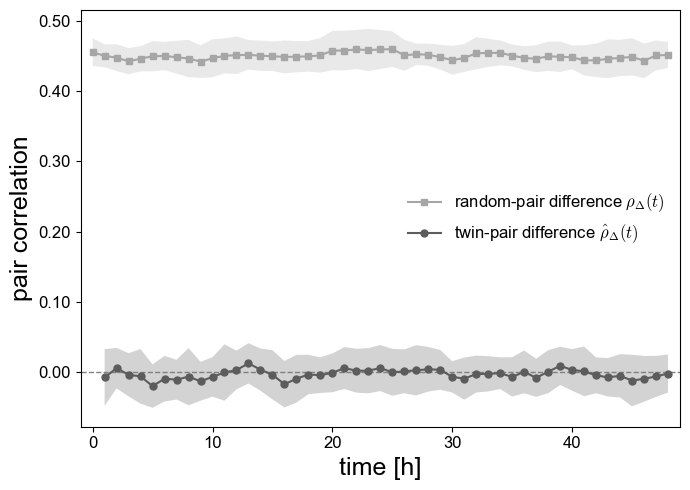

In [51]:
import pandas as pd
from pathlib import Path
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

folder_name = "A_B_2_states"

results_df = pd.read_csv(
    f"{path_to_data}/twin_correlation_over_time_{folder_name}.csv"
)

# Aggregate over replicates
agg_twin = (
    results_df.groupby("time_step")[["twin_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)
agg_random = (
    results_df.groupby("time_step")[["random_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)

# Flatten multiindex columns
agg_twin.columns = ["_".join(col) for col in agg_twin.columns]
agg_random.columns = ["_".join(col) for col in agg_random.columns]

agg_twin = agg_twin.reset_index()
agg_random = agg_random.reset_index()

mean_twin = agg_twin["twin_corr_gene1_gene2_mean"]
std_twin = agg_twin["twin_corr_gene1_gene2_std"]
mean_random = agg_random["random_corr_gene1_gene2_mean"]
std_random = agg_random["random_corr_gene1_gene2_std"]


fig, ax = plt.subplots(figsize=(7, 5))

# === Random shaded region ===
x_random = agg_random["time_step"].values
y_upper_random = (mean_random + std_random).values
y_lower_random = (mean_random - std_random).values

vertices_random = np.vstack([
    np.column_stack([x_random, y_upper_random]),
    np.column_stack([x_random[::-1], y_lower_random[::-1]])
])

polygon_random = Polygon(vertices_random, alpha=0.3, facecolor="#b8b8b8", edgecolor="none", zorder=0)
ax.add_patch(polygon_random)

# === Twin shaded region ===
x_twin = agg_twin["time_step"].values
y_upper_twin = (mean_twin + std_twin).values
y_lower_twin = (mean_twin - std_twin).values

vertices_twin = np.vstack([
    np.column_stack([x_twin, y_upper_twin]),
    np.column_stack([x_twin[::-1], y_lower_twin[::-1]])
])

polygon_twin = Polygon(vertices_twin, alpha=0.3, facecolor="#707070", edgecolor="none", zorder=1)
ax.add_patch(polygon_twin)

# === Mean lines (LaTeX labels) ===

ax.plot(
    agg_random["time_step"],
    mean_random,
    marker="s", 
    markersize=5,
    color="#a6a6a6",
    label="random-pair difference " + r"$\rho_{\Delta}(t)$",
    zorder=2
)

ax.plot(
    agg_twin["time_step"],
    mean_twin,
    marker="o",
    markersize=5,
    color="#5c5c5c",
    label= "twin-pair difference " + r"$\hat{\rho}_{\Delta}(t)$",
    zorder=3
)



# Reference line
ax.axhline(y=0.0, linestyle="--", color="gray", linewidth=1)

# Labels
ax.set_xlabel("time [h]")
ax.set_ylabel("pair correlation")
import matplotlib.ticker as mticker

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# Legend
ax.legend(frameon=False, loc='center right')

# Limits
ax.set_xlim(agg_twin["time_step"].min() - 1, agg_twin["time_step"].max() + 1)

plt.tight_layout()

# Save
outdir = Path(path_to_plots)
outdir.mkdir(exist_ok=True)

svg_path = outdir / f"twin_correlation_over_time_{folder_name}.svg"
pdf_path = outdir / f"twin_correlation_over_time_{folder_name}.pdf"
png_path = outdir / f"twin_correlation_over_time_{folder_name}.png"


plt.savefig(svg_path, format="svg", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(pdf_path, format="pdf", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(png_path, format="png", bbox_inches='tight', dpi=600, facecolor="none", edgecolor="none", transparent=True)

print("Saved:")
print(" ", svg_path)
print(" ", png_path)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
t1 = 1
t2 = 20
# Paths
folder_name = "A_to_B_2_states"
low_folder  = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_low_k_on")
high_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_high_k_on")

low_csvs  = sorted(low_folder.glob("df_rows_*.csv"))
high_csvs = sorted(high_folder.glob("df_rows_*.csv"))

path_to_connectivity_matrix = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/connectivity_matrix_A_to_B.txt"
n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]
results = []
# Parameters
seed = 1010


rng = np.random.default_rng(seed)

# --- match by replicate number ---
def get_rep_number(path):
    # extract final "rep_X" from filename
    return int(path.stem.split("_rep_")[-1])

# dictionary: rep → path
low_by_rep  = {get_rep_number(p): p for p in low_csvs}
high_by_rep = {get_rep_number(p): p for p in high_csvs}

# process only reps present in BOTH
common_reps = sorted(set(low_by_rep) & set(high_by_rep))

for rep in common_reps:
    pair_paths = [low_by_rep[rep], high_by_rep[rep]]
    
    # --- 1. split + merge ---
    simulation = split_and_merge_simulations(pair_paths)
    n_clones_simulation = simulation['clone_id'].nunique()
    
    # Shuffle clones
    clone_ids_shuffled = np.random.permutation(n_clones_simulation)
    n1 = n2 = n_clones_simulation // 4
    t1_clones = clone_ids_shuffled[:n1]
    t2_clones = clone_ids_shuffled[n1:n1 + n2]
    across_t_clones = clone_ids_shuffled[n1 + n2:]
    
    t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]
    t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

    # Across_t: pick exactly one random twin per clone_id
    # One cell per clone at t1
    across_t_twin1 = (
        simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
    )
    
    across_t_twin2 = (
        simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
    )

    # Reset index for cleanliness
    t1_twins = t1_twins.reset_index(drop=True)
    t2_twins = t2_twins.reset_index(drop=True)
    across_t_twin1 = across_t_twin1.reset_index(drop=True)
    across_t_twin2 = across_t_twin2.reset_index(drop=True)

    all_t1_t2_measurements = pd.concat(
    [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
    ignore_index=True
    )

    # Loop across all time points available
    for t1 in sorted(simulation['time_step'].unique()):
        # Twins at this time
        t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)]
        t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

        # Across_t: pick exactly one random twin per clone_id
        # One cell per clone at t1
        across_t_twin1 = (
            simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
        )
        
        across_t_twin2 = (
            simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
        )

        # Reset index for cleanliness
        t1_twins = t1_twins.reset_index(drop=True)
        t2_twins = t2_twins.reset_index(drop=True)
        across_t_twin1 = across_t_twin1.reset_index(drop=True)
        across_t_twin2 = across_t_twin2.reset_index(drop=True)

        all_t1_t2_measurements = pd.concat(
        [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
        ignore_index=True
        )
        if t1_twins.empty:
            continue
        
        # Pairwise gene–gene correlation matrix
        twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
        all_t1_t2_measurements, t1_twins, gene_list
        )
        
        # Twin correlation (example: gene_1 vs gene_2)
        twin_corr = twin_pair_correlation_matrix_t1.loc['gene_1', 'gene_2']
        random_corr = random_pair_correlation_matrix_t2.loc['gene_1', 'gene_2']
        results.append({
            "file_low": low_by_rep[rep].name,
            "file_high": high_by_rep[rep].name,
            "time_step": t1,
            "twin_corr_gene1_gene2": twin_corr,
            "random_corr_gene1_gene2": random_corr
        })

# Collect into DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["file_low", "time_step"]).reset_index(drop=True)

# # Save table (optional)
results_df.to_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/twin_correlation_over_time_{folder_name}.csv", index=False)


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved:
  /home/keerthm/twinfer/plots/twin_correlation_over_time_A_to_B_2_states.svg
  /home/keerthm/twinfer/plots/twin_correlation_over_time_A_to_B_2_states.png


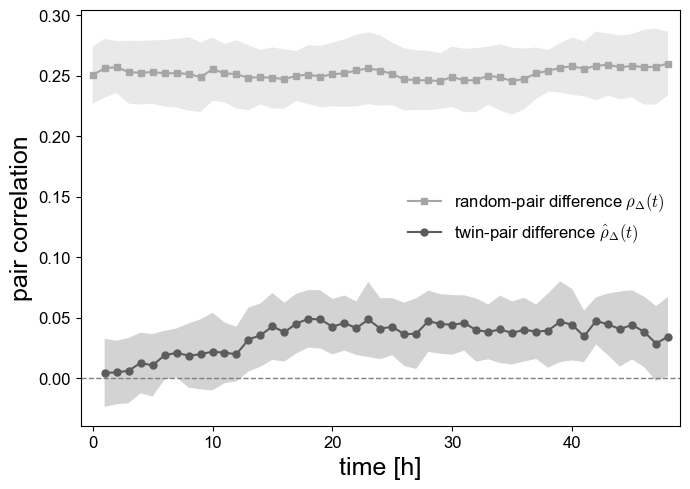

In [52]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from pathlib import Path
from matplotlib.patches import Polygon
import numpy as np

folder_name = "A_to_B_2_states"
#
# Load data
results_df = pd.read_csv(
    f"{path_to_data}/twin_correlation_over_time_{folder_name}.csv"
)

# Aggregate over replicates
agg_twin = (
    results_df.groupby("time_step")[["twin_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)
agg_random = (
    results_df.groupby("time_step")[["random_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)

# Flatten multiindex columns
agg_twin.columns = ["_".join(col) for col in agg_twin.columns]
agg_random.columns = ["_".join(col) for col in agg_random.columns]

agg_twin = agg_twin.reset_index()
agg_random = agg_random.reset_index()

mean_twin = agg_twin["twin_corr_gene1_gene2_mean"]
std_twin = agg_twin["twin_corr_gene1_gene2_std"]
mean_random = agg_random["random_corr_gene1_gene2_mean"]
std_random = agg_random["random_corr_gene1_gene2_std"]


fig, ax = plt.subplots(figsize=(7, 5))

# === Random shaded region ===
x_random = agg_random["time_step"].values
y_upper_random = (mean_random + std_random).values
y_lower_random = (mean_random - std_random).values

vertices_random = np.vstack([
    np.column_stack([x_random, y_upper_random]),
    np.column_stack([x_random[::-1], y_lower_random[::-1]])
])

polygon_random = Polygon(vertices_random, alpha=0.3, facecolor="#b8b8b8", edgecolor="none", zorder=0)
ax.add_patch(polygon_random)

# === Twin shaded region ===
x_twin = agg_twin["time_step"].values
y_upper_twin = (mean_twin + std_twin).values
y_lower_twin = (mean_twin - std_twin).values

vertices_twin = np.vstack([
    np.column_stack([x_twin, y_upper_twin]),
    np.column_stack([x_twin[::-1], y_lower_twin[::-1]])
])

polygon_twin = Polygon(vertices_twin, alpha=0.3, facecolor="#707070", edgecolor="none", zorder=1)
ax.add_patch(polygon_twin)

# === Mean lines (LaTeX labels) ===
ax.plot(
    agg_random["time_step"],
    mean_random,
    marker="s", 
    markersize=5,
    color="#a6a6a6",
    label="random-pair difference " + r"$\rho_{\Delta}(t)$",
    zorder=2
)

ax.plot(
    agg_twin["time_step"],
    mean_twin,
    marker="o",
    markersize=5,
    color="#5c5c5c",
    label= "twin-pair difference " + r"$\hat{\rho}_{\Delta}(t)$",
    zorder=3
)



# Reference line
ax.axhline(y=0.0, linestyle="--", color="gray", linewidth=1)

# Labels
ax.set_xlabel("time [h]")
ax.set_ylabel("pair correlation")
import matplotlib.ticker as mticker

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# Legend
ax.legend(frameon=False, loc='center right')

# Limits
ax.set_xlim(agg_twin["time_step"].min() - 1, agg_twin["time_step"].max() + 1)

plt.tight_layout()

# Save
outdir = Path(path_to_plots)
outdir.mkdir(exist_ok=True)

svg_path = outdir / f"twin_correlation_over_time_{folder_name}.svg"
pdf_path = outdir / f"twin_correlation_over_time_{folder_name}.pdf"
png_path = outdir / f"twin_correlation_over_time_{folder_name}.png"


plt.savefig(svg_path, format="svg", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(pdf_path, format="pdf", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(png_path, format="png", bbox_inches='tight', dpi=600, facecolor="none", edgecolor="none", transparent=True)

print("Saved:")
print(" ", svg_path)
print(" ", png_path)

plt.show()

# Directional correlation

In [53]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.stats import spearmanr
import numpy as np
import matplotlib.patches as patches


def fast_corr(x, y):
    """Compute Spearman correlation between two 1D arrays."""
    corr, _ = spearmanr(x, y)
    return corr

def shuffle_test(x, y, threshold=0.01, n_shuffles=5000, rng=None):
    """Return True if Spearman correlation passes shuffle test."""
    actual_corr = fast_corr(x, y)

    # Create shuffled versions of y
    shuffles = np.array([rng.permutation(y) for _ in range(n_shuffles)])
    
    # Compute Spearman correlation for each shuffle
    shuffled_corrs = np.array([fast_corr(x, yy) for yy in shuffles])

    # Determine significance cutoff
    from scipy.stats import percentileofscore

    percentile_score = percentileofscore(np.abs(shuffled_corrs), abs(actual_corr))
    print(percentile_score)  # e.g. 97.3 means it's higher than 97.3% of values

    return percentile_score, actual_corr


# ------------------------------------------------
# Per time-pair function
# ------------------------------------------------
def process_time_pair(t1, t2, across_t_twin1, across_t_twin2,
                      csv_name, rng, all_gene_pairs, gene_pair,
                      threshold=0.01, n_shuffles=5000):
    if across_t_twin1.empty or across_t_twin2.empty:
        return None
        

    # Compute raw + normalized matrices for all gene pairs
    direction_raw_matrix, direction_normalized_matrix = get_cross_correlations(
        across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs
    )
    g1, g2 = gene_pair[0]
    if g1 not in direction_raw_matrix.index or g2 not in direction_raw_matrix.columns:
        return None

    raw_val = direction_raw_matrix.loc[g1, g2]
    norm_val = direction_normalized_matrix.loc[g1, g2]

    # Shuffle test on raw values
    x = across_t_twin1[f"{g1}_mRNA"].values
    y = across_t_twin2[f"{g2}_mRNA"].values
    percentile_score,_ = shuffle_test(x, y, threshold=threshold, n_shuffles=n_shuffles, rng=rng)

    

    return {
        "file": csv_name,
        "t1": t1,
        "t2": t2,
        "raw_corr": raw_val,
        "normalized_corr": norm_val,
        "percentile_score": percentile_score
    }

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_triangle_correlation_value_mask(heatmap_data, figsize=(10, 8)):
    # Ensure numeric, ascending axes
    H = heatmap_data.copy()
    H.index = H.index.astype(float)
    H.columns = H.columns.astype(float)
    H = H.sort_index().sort_index(axis=1)

    # ---- value-based mask: hide cells where t2 < t1 ----
    x = H.columns.values  # t1 values
    y = H.index.values    # t2 values
    mask = (y[:, None] < x[None, :])   # True => hidden

    # Colormap with grey at zero
    base = plt.cm.RdBu(np.linspace(0, 1, 256))
    base[128] = np.array([0.85, 0.85, 0.85, 1.0])  # grey for 0
    cmap = ListedColormap(base)

    fig, ax = plt.subplots(figsize=figsize)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.8)

    # Heatmap
    hm = sns.heatmap(
        H, mask=mask, cmap=cmap, vmin=-0.2, vmax=0.2, square=True,
        linewidths=0.5, linecolor="white", ax=ax,
        cbar_ax=cax, cbar_kws={"orientation": "horizontal"}
    )

    # Put x on bottom
    ax.xaxis.set_ticks_position("bottom")
    ax.xaxis.set_label_position("bottom")
    ax.set_xlabel(r"$t_{1}$ [h]")
    ax.set_ylabel(r"$t_{2}$ [h]")
    ax.invert_yaxis()

    # Tick every 5h
    def set_ticks(vals, axis="x"):
        want = np.arange(0, int(vals.max()) + 1, 5)
        pos = [np.where(np.isclose(vals, v))[0][0] + 0.5 for v in want if v in vals]
        lab = [int(v) for v in want if v in vals]
        if axis == "x":
            ax.set_xticks(pos); ax.set_xticklabels(lab, rotation=0)
        else:
            ax.set_yticks(pos); ax.set_yticklabels(lab, rotation=0)

    set_ticks(x, "x")
    set_ticks(y, "y")

    # Colorbar
    cbar = ax.collections[0].colorbar
    cbar.set_label(
        "twin cross-correlation " + r"$\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
        labelpad=10
    )
    cbar.ax.tick_params(labelsize=14)

    # Add rectangle border
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    rect = patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        linewidth=1.5, edgecolor="black", facecolor="none"
    )
    rect.set_clip_on(False)
    ax.add_patch(rect)

    # ---- Remove clipping masks for ALL artists ----
    for ax_ in [ax, cax]:
        for artist in ax_.get_children():
            if hasattr(artist, "set_clip_on"):
                artist.set_clip_on(False)

    plt.tight_layout()
    return plt




'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


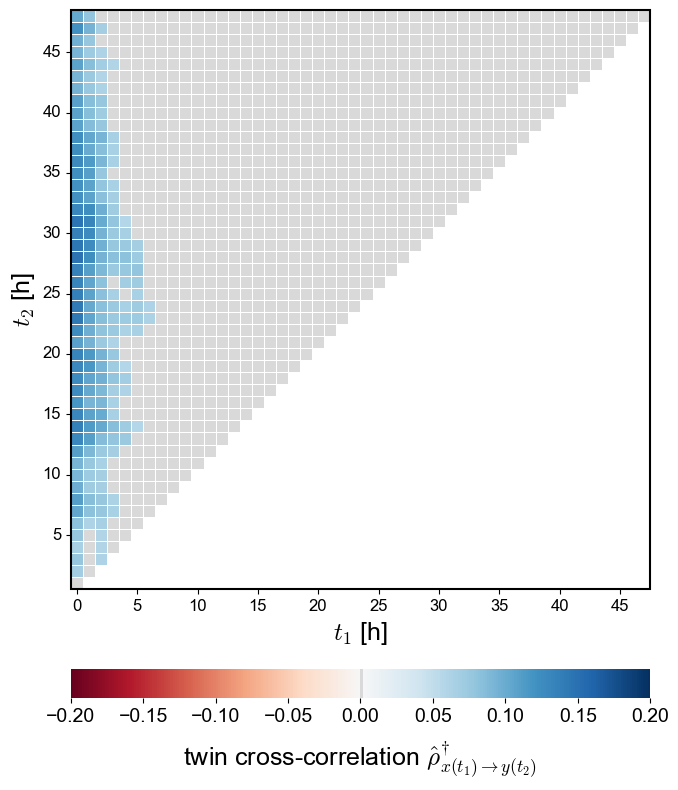

In [54]:
# ------------------------------------------------
# Main loop
# ------------------------------------------------
# seed = 1010
# rng = np.random.default_rng(seed)
# p_value_threshold_cross_correlation = 0.01
# n_shuffles = 10000
# gene_pair = [("gene_1", "gene_2")]   # <-- the pair you care about

# folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/"
#               "median_parameter_simulations/figure_2_simulations_6000_cells/A_to_B/")

# results = []
# for i, csv_path in enumerate(folder.glob("df_rows_*.csv")):
#     if i > 0:   # just first file for now
#         break

#     simulation = pd.read_csv(csv_path)
#     n_clones_simulation = simulation['clone_id'].nunique()

#     # shuffle clones
#     clone_ids_shuffled = rng.permutation(n_clones_simulation)
#     n1 = n2 = n_clones_simulation // 4
#     across_t_clones = clone_ids_shuffled[n1 + n2:]

#     all_times = sorted(simulation['time_step'].unique())
#     tasks = []
#     for t1 in all_times:
#         for t2 in all_times:
#             if t1 >= t2:
#                 continue
#             across_t_twin1 = simulation[
#                 (simulation['clone_id'].isin(across_t_clones)) &
#                 (simulation['time_step'] == t1) &
#                 (simulation['replicate'] == 1)
#             ]
#             across_t_twin2 = simulation[
#                 (simulation['clone_id'].isin(across_t_clones)) &
#                 (simulation['time_step'] == t2) &
#                 (simulation['replicate'] == 2)
#             ]
#             tasks.append((t1, t2, across_t_twin1, across_t_twin2, csv_path.name))
    
#     with tqdm_joblib(tqdm(desc="Processing tasks", total=len(tasks))):
#         parallel_results = Parallel(n_jobs=-1)(
#             delayed(process_time_pair)(*task, rng, all_gene_pairs=gene_pair,  # supply your pairs list
#                                     gene_pair=gene_pair,
#                                     threshold=p_value_threshold_cross_correlation,
#                                     n_shuffles=n_shuffles)
#             for task in tasks
#         )
#     results.extend([res for res in parallel_results if res is not None])

# # ------------------------------------------------
# # Aggregate results
# # ------------------------------------------------
# results_df = pd.DataFrame(results)


# results_df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/directional_corr_t1_t2.csv")
results_df = pd.read_csv(f"{path_to_data}/directional_corr_t1_t2.csv")

# Build heatmap grid
t1_vals = sorted(results_df["t1"].unique())
t2_vals = sorted(results_df["t2"].unique())

results_df_filtered = results_df.copy()
results_df_filtered.loc[results_df_filtered["percentile_score"] < 99.9, "raw_corr"] = 0

norm_heatmap = (
    results_df_filtered
    .pivot_table(index="t2", columns="t1", values="raw_corr", aggfunc="mean")
    .reindex(index=t2_vals, columns=t1_vals)  # ensure full axes
)

plt = plot_triangle_correlation_value_mask(norm_heatmap)
plt.savefig(
    f"{path_to_plots}/directional_raw_corr_t1_t2_A_to_B.svg",
    format="svg",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/directional_raw_corr_t1_t2_A_to_B.pdf",
    format="pdf",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/directional_raw_corr_t1_t2_A_to_B.png",
    format="png",
    facecolor="none",
    edgecolor="none",
    transparent=True
)


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


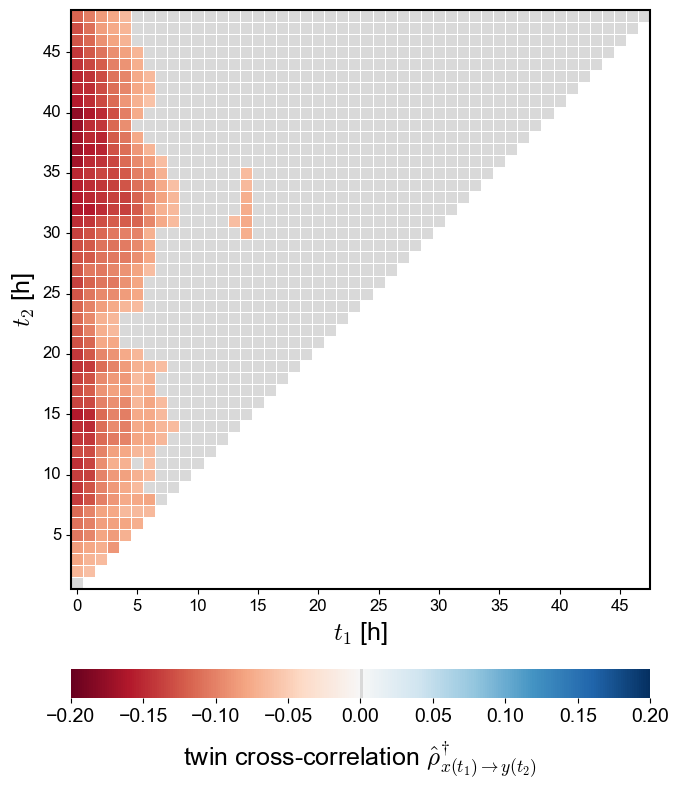

In [55]:
# # ------------------------------------------------
# # Main loop
# # ------------------------------------------------
# seed = 1010
# rng = np.random.default_rng(seed)
# p_value_threshold_cross_correlation = 0.01
# n_shuffles = 10000
# gene_pair = [("gene_1", "gene_2")]   # <-- the pair you care about

# folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/"
#               "median_parameter_simulations/figure_2_simulations_6000_cells/A_rep_B/")

# results = []
# for i, csv_path in enumerate(folder.glob("df_rows_*.csv")):
#     if i > 0:   # just first file for now
#         break

#     simulation = pd.read_csv(csv_path)
#     n_clones_simulation = simulation['clone_id'].nunique()

#     # shuffle clones
#     clone_ids_shuffled = rng.permutation(n_clones_simulation)
#     n1 = n2 = n_clones_simulation // 4
#     across_t_clones = clone_ids_shuffled[n1 + n2:]

#     all_times = sorted(simulation['time_step'].unique())
#     tasks = []
#     for t1 in all_times:
#         for t2 in all_times:
#             if t1 >= t2:
#                 continue
#             across_t_twin1 = simulation[
#                 (simulation['clone_id'].isin(across_t_clones)) &
#                 (simulation['time_step'] == t1) &
#                 (simulation['replicate'] == 1)
#             ]
#             across_t_twin2 = simulation[
#                 (simulation['clone_id'].isin(across_t_clones)) &
#                 (simulation['time_step'] == t2) &
#                 (simulation['replicate'] == 2)
#             ]
#             tasks.append((t1, t2, across_t_twin1, across_t_twin2, csv_path.name))
    
#     with tqdm_joblib(tqdm(desc="Processing tasks", total=len(tasks))):
#         parallel_results = Parallel(n_jobs=-1)(
#             delayed(process_time_pair)(*task, rng, all_gene_pairs=gene_pair,  # supply your pairs list
#                                     gene_pair=gene_pair,
#                                     threshold=p_value_threshold_cross_correlation,
#                                     n_shuffles=n_shuffles)
#             for task in tasks
#         )
#     results.extend([res for res in parallel_results if res is not None])

# # ------------------------------------------------
# # Aggregate results
# # ------------------------------------------------
# results_df = pd.DataFrame(results)


# results_df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/directional_corr_t1_t2_A_rep_B.csv")
results_df = pd.read_csv(f"{path_to_data}/directional_corr_t1_t2_A_rep_B.csv")

# Build heatmap grid
t1_vals = sorted(results_df["t1"].unique())
t2_vals = sorted(results_df["t2"].unique())

results_df_filtered = results_df.copy()
results_df_filtered.loc[results_df_filtered["percentile_score"] < 99.9, "raw_corr"] = 0

norm_heatmap = (
    results_df_filtered
    .pivot_table(index="t2", columns="t1", values="raw_corr", aggfunc="mean")
    .reindex(index=t2_vals, columns=t1_vals)  # ensure full axes
)

plt = plot_triangle_correlation_value_mask(norm_heatmap)
plt.savefig(
    f"{path_to_plots}/directional_raw_corr_t1_t2_A_rep_B.svg",
    format="svg",
    facecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/directional_raw_corr_t1_t2_A_rep_B.pdf",
    format="pdf",
    facecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/directional_raw_corr_t1_t2_A_rep_B.png",
    format="png",
    facecolor="none",
    transparent=True
)


# Scrambled distributions

## Gene-gene correlations

In [2]:
def compute_correlation_matrix(gene_matrix_1, gene_matrix_2, gene_list, gene_pairs=None):
   """Compute Spearman correlations between gene expression matrices."""
   n_genes = len(gene_list)
   gene_to_idx = {gene: i for i, gene in enumerate(gene_list)}
   raw_matrix = np.zeros((n_genes, n_genes))
   
   # Determine which pairs to compute
   if gene_pairs is None:
       pairs_to_compute = [(i, j) for i in range(n_genes) for j in range(n_genes)]
   else:
       pairs_to_compute = []
       for gene_1, gene_2 in gene_pairs:
           if gene_1 in gene_to_idx and gene_2 in gene_to_idx:
               i, j = gene_to_idx[gene_1], gene_to_idx[gene_2]
               pairs_to_compute.append((i, j))
   
   # Compute correlations
   for i, j in pairs_to_compute:
       corr = spearmanr(gene_matrix_1[i, :], gene_matrix_2[j, :]).correlation
       raw_matrix[i, j] = corr if not np.isnan(corr) else 0.0
   
   return pd.DataFrame(raw_matrix, index=gene_list, columns=gene_list)

def single_cell_shuffle(gene_matrix_1, gene_matrix_2, gene_list, shuffle_pairs):
            n_cells = gene_matrix_1.shape[1]
            shuffled_indices = np.random.permutation(n_cells)
            return compute_correlation_matrix(gene_matrix_1, gene_matrix_2[:, shuffled_indices], 
                                                  gene_list, shuffle_pairs)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


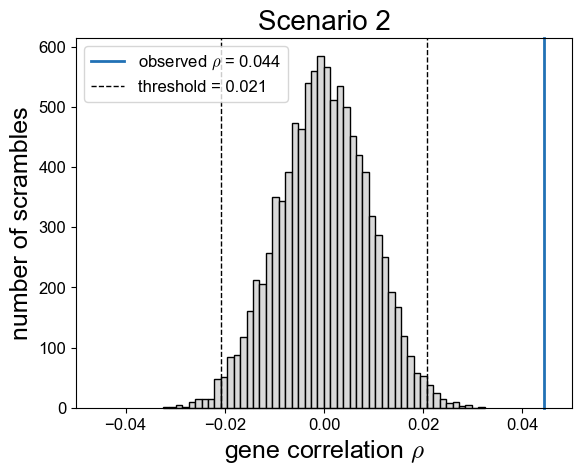

In [97]:
# from itertools import combinations
# csv_path = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B/df_rows_0_1_05082025_160041_ncells_6000_A_to_B_rep_0.csv"
# simulation = pd.read_csv(csv_path)
# path_to_connectivity_matrix = f"//home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/interaction_matrix_A_to_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )

# pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
#         all_t1_t2_measurements, gene_list
#     )

# # Extract gene matrices from DataFrame
# gene_matrix = []

# for gene in gene_list:
#     # Look for gene columns (adapt this to your column naming)
#     gene_col = f"{gene}_mRNA"  # Adjust this pattern as needed
#     if gene_col in all_t1_t2_measurements.columns:
#         # Split by time point or condition - adjust this logic for your data structure
#         gene_data = all_t1_t2_measurements[gene_col].values
#         gene_matrix.append(gene_data)
#     else:
#         raise ValueError(f"Could not find column for gene: {gene}")

# gene_matrix = np.array(gene_matrix)  # Shape: (n_genes, n_cells)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs

# pair_correlations = {(gi, gj): pairwise_gene_gene_correlation_matrix.loc[gi, gj] for gi, gj in all_pairs}
      
#     # Generate null distribution
    
# n_cores_to_use = max(1, os.cpu_count() - 2)
# shuffled_results = Parallel(n_jobs=n_cores_to_use, verbose=0)(
#         delayed(single_cell_shuffle)(gene_matrix, gene_matrix, gene_list, all_pairs) 
#         for _ in range(n_shuffles)
# )
    
# percentile_threshold = (1 - p_val_threshold) * 100

# no_regulation, potential_regulation = [], []

outname = f"gene_gene_corr_A_to_B" 

# gi, gj = all_pairs [0]
# corr_val = pair_correlations[(gi, gj)]
# shuffled_vals = [r.loc[gi, gj] for r in shuffled_results]
# current_threshold = np.percentile(shuffled_vals, percentile_threshold)
# p_value = np.mean(np.array(shuffled_vals) >= abs(corr_val))
# direction_str = "-"


# df_out = pd.DataFrame({
#         "pair": f"{gi}_{gj}",
#         "shuffled_vals": shuffled_vals
#     })
# df_out["actual_corr"] = corr_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value

# df_out.to_csv(f"{path_to_data}/{outname}.csv", index=False)
df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")


df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "blue"  # or "red", "grey"




fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.xlim(-0.05, 0.05)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 2")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.show()



    

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


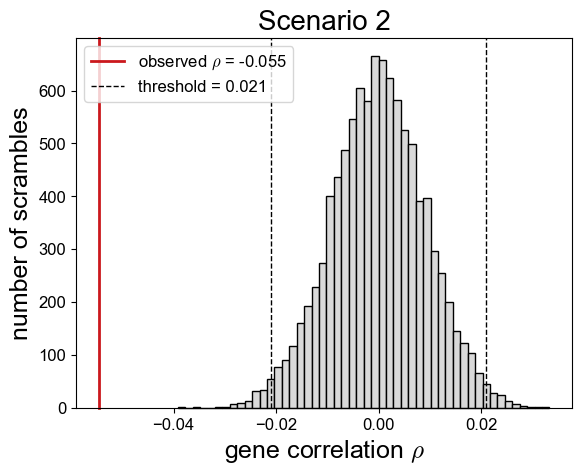

In [ ]:
# from itertools import combinations, permutations
# csv_path = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_3_simulations/A_rep_B/df_rows_6_6_22082025_150451_ncells_6000_A_represses_B_rep_0_b0755906.csv"
# simulation = pd.read_csv(csv_path)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/connectivity_matrix_A_rep_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )

# pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
#         all_t1_t2_measurements, gene_list
#     )

# # Extract gene matrices from DataFrame
# gene_matrix = []

# for gene in gene_list:
#     # Look for gene columns (adapt this to your column naming)
#     gene_col = f"{gene}_mRNA"  # Adjust this pattern as needed
#     if gene_col in all_t1_t2_measurements.columns:
#         # Split by time point or condition - adjust this logic for your data structure
#         gene_data = all_t1_t2_measurements[gene_col].values
#         gene_matrix.append(gene_data)
#     else:
#         raise ValueError(f"Could not find column for gene: {gene}")

# gene_matrix = np.array(gene_matrix)  # Shape: (n_genes, n_cells)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs

# pair_correlations = {(gi, gj): pairwise_gene_gene_correlation_matrix.loc[gi, gj] for gi, gj in all_pairs}
      
#     # Generate null distribution
    
# n_cores_to_use = max(1, os.cpu_count() - 2)
# shuffled_results = Parallel(n_jobs=n_cores_to_use, verbose=0)(
#         delayed(single_cell_shuffle)(gene_matrix, gene_matrix, gene_list, all_pairs) 
#         for _ in range(n_shuffles)
# )
    
# percentile_threshold = (1 - p_val_threshold) * 100

# no_regulation, potential_regulation = [], []

outname = f"gene_gene_corr_A_rep_B"
# gi, gj = all_pairs [0]
# corr_val = pair_correlations[(gi, gj)]
# shuffled_vals = [r.loc[gi, gj] for r in shuffled_results]
# current_threshold = np.percentile(shuffled_vals, percentile_threshold)
# p_value = np.mean(np.array(shuffled_vals) >= abs(corr_val))
# direction_str = "-"


# df_out = pd.DataFrame({
#         "pair": f"{gi}_{gj}",
#         "shuffled_vals": shuffled_vals
#     })
# df_out["actual_corr"] = corr_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value

# df_out.to_csv(f"{path_to_data}/{outname}.csv", index=False)
df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options

choice = "red"  # or "red", "grey"

fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 2")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


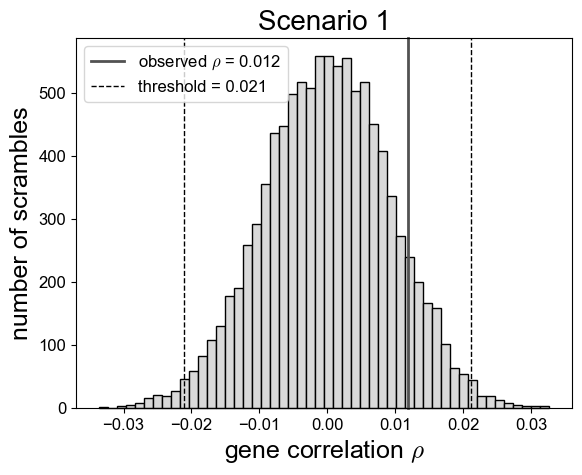

In [95]:
# from itertools import combinations
# csv_path = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B/df_rows_0_1_08082025_093223_ncells_6000_A_B_rep_0.csv"
# simulation = pd.read_csv(csv_path)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/connectivity_matrix_A_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )

# pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
#         all_t1_t2_measurements, gene_list
#     )

# # Extract gene matrices from DataFrame
# gene_matrix = []

# for gene in gene_list:
#     # Look for gene columns (adapt this to your column naming)
#     gene_col = f"{gene}_mRNA"  # Adjust this pattern as needed
#     if gene_col in all_t1_t2_measurements.columns:
#         # Split by time point or condition - adjust this logic for your data structure
#         gene_data = all_t1_t2_measurements[gene_col].values
#         gene_matrix.append(gene_data)
#     else:
#         raise ValueError(f"Could not find column for gene: {gene}")

# gene_matrix = np.array(gene_matrix)  # Shape: (n_genes, n_cells)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs

# pair_correlations = {(gi, gj): pairwise_gene_gene_correlation_matrix.loc[gi, gj] for gi, gj in all_pairs}
      
#     # Generate null distribution
    
# n_cores_to_use = max(1, os.cpu_count() - 2)
# shuffled_results = Parallel(n_jobs=n_cores_to_use, verbose=0)(
#         delayed(single_cell_shuffle)(gene_matrix, gene_matrix, gene_list, all_pairs) 
#         for _ in range(n_shuffles)
# )
    
# percentile_threshold = (1 - p_val_threshold) * 100

# no_regulation, potential_regulation = [], []

outname = f"gene_gene_corr_A_B"

# gi, gj = all_pairs [0]
# corr_val = pair_correlations[(gi, gj)]
# shuffled_vals = [r.loc[gi, gj] for r in shuffled_results]
# current_threshold = np.percentile(shuffled_vals, percentile_threshold)
# p_value = np.mean(np.array(shuffled_vals) >= abs(corr_val))
# direction_str = "-"


# df_out = pd.DataFrame({
#         "pair": f"{gi}_{gj}",
#         "shuffled_vals": shuffled_vals
#     })
# df_out["actual_corr"] = corr_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value

# df_out.to_csv(f"{path_to_data}/{outname}.csv", index=False)
df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "grey"  # or "red", "grey"




fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 1")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


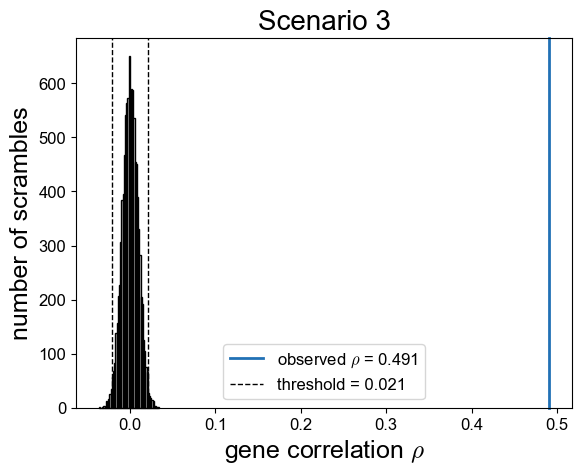

In [94]:
# ####CURRENT###########
# from itertools import combinations
# csv_path_low = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_low_k_on/df_rows_2_2_09082025_210256_ncells_6000_A_B_low_k_on_rep_0.csv"
# csv_path_high = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_high_k_on/df_rows_3_3_09082025_201359_ncells_6000_A_B_high_k_on_rep_0.csv"

# simulation = split_and_merge_simulations([csv_path_low, csv_path_high])
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/connectivity_matrix_A_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )

# pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
#         all_t1_t2_measurements, gene_list
#     )

# # Extract gene matrices from DataFrame
# gene_matrix = []

# for gene in gene_list:
#     # Look for gene columns (adapt this to your column naming)
#     gene_col = f"{gene}_mRNA"  # Adjust this pattern as needed
#     if gene_col in all_t1_t2_measurements.columns:
#         # Split by time point or condition - adjust this logic for your data structure
#         gene_data = all_t1_t2_measurements[gene_col].values
#         gene_matrix.append(gene_data)
#     else:
#         raise ValueError(f"Could not find column for gene: {gene}")

# gene_matrix = np.array(gene_matrix)  # Shape: (n_genes, n_cells)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs

# pair_correlations = {(gi, gj): pairwise_gene_gene_correlation_matrix.loc[gi, gj] for gi, gj in all_pairs}
      
#     # Generate null distribution
    
# n_cores_to_use = max(1, os.cpu_count() - 2)
# shuffled_results = Parallel(n_jobs=n_cores_to_use, verbose=0)(
#         delayed(single_cell_shuffle)(gene_matrix, gene_matrix, gene_list, all_pairs) 
#         for _ in range(n_shuffles)
# )
    
# percentile_threshold = (1 - p_val_threshold) * 100
outname = f"gene_gene_corr_A_B_multistate"
# gi, gj = all_pairs [0]
# corr_val = pair_correlations[(gi, gj)]
# shuffled_vals = [r.loc[gi, gj] for r in shuffled_results]
# current_threshold = np.percentile(shuffled_vals, percentile_threshold)
# p_value = np.mean(np.array(shuffled_vals) >= abs(corr_val))
# direction_str = "-"


# df_out = pd.DataFrame({
#         "pair": f"{gi}_{gj}",
#         "shuffled_vals": shuffled_vals
#     })
# df_out["actual_corr"] = corr_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value

# df_out.to_csv(f"{path_to_data}/{outname}.csv", index=False)
df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "blue"  # or "red", "grey"

fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 3")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.show()

    

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


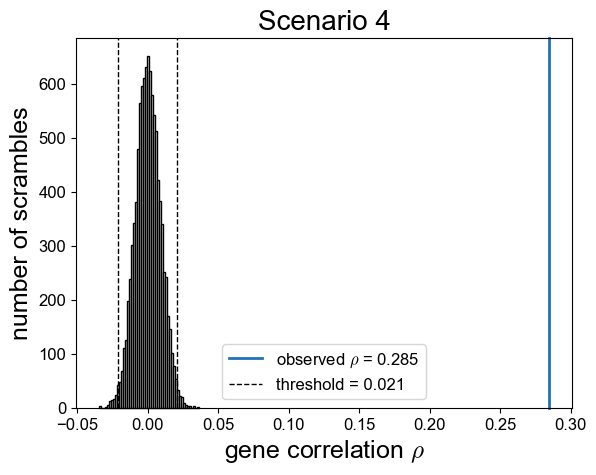

In [93]:
# from itertools import combinations
# csv_path_low = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_low_k_on/df_rows_2_2_09082025_212311_ncells_6000_A_to_B_low_k_on_rep_0.csv"
# csv_path_high = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_0.csv"

# simulation = split_and_merge_simulations([csv_path_low, csv_path_high])
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/interaction_matrix_A_to_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )

# pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
#         all_t1_t2_measurements, gene_list
#     )

# # Extract gene matrices from DataFrame
# gene_matrix = []

# for gene in gene_list:
#     # Look for gene columns (adapt this to your column naming)
#     gene_col = f"{gene}_mRNA"  # Adjust this pattern as needed
#     if gene_col in all_t1_t2_measurements.columns:
#         # Split by time point or condition - adjust this logic for your data structure
#         gene_data = all_t1_t2_measurements[gene_col].values
#         gene_matrix.append(gene_data)
#     else:
#         raise ValueError(f"Could not find column for gene: {gene}")

# gene_matrix = np.array(gene_matrix)  # Shape: (n_genes, n_cells)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs

# pair_correlations = {(gi, gj): pairwise_gene_gene_correlation_matrix.loc[gi, gj] for gi, gj in all_pairs}
      
#     # Generate null distribution
    
# n_cores_to_use = max(1, os.cpu_count() - 2)
# shuffled_results = Parallel(n_jobs=n_cores_to_use, verbose=0)(
#         delayed(single_cell_shuffle)(gene_matrix, gene_matrix, gene_list, all_pairs) 
#         for _ in range(n_shuffles)
# )
    
# percentile_threshold = (1 - p_val_threshold) * 100

# no_regulation, potential_regulation = [], []
outname = f"gene_gene_corr_A_to_B_multistate"
# gi, gj = all_pairs [0]
# corr_val = pair_correlations[(gi, gj)]
# shuffled_vals = [r.loc[gi, gj] for r in shuffled_results]
# current_threshold = np.percentile(shuffled_vals, percentile_threshold)
# p_value = np.mean(np.array(shuffled_vals) >= abs(corr_val))
# direction_str = "-"


# df_out = pd.DataFrame({
#         "pair": f"{gi}_{gj}",
#         "shuffled_vals": shuffled_vals
#     })
# df_out["actual_corr"] = corr_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value

# df_out.to_csv(f"{path_to_data}/{outname}.csv", index=False)
df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "blue"  # or "red", "grey"

fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 4")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.show()


## Twin vs random

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


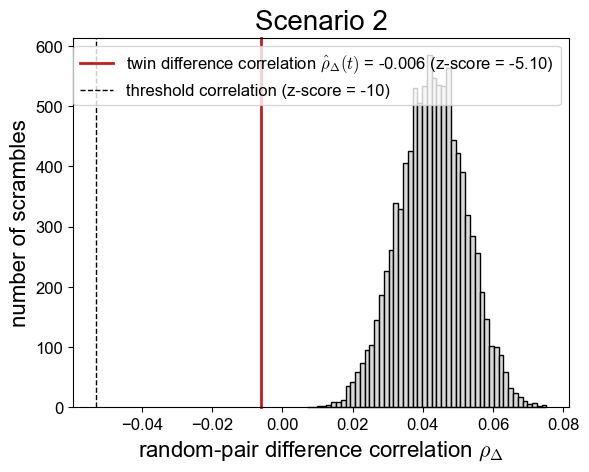

In [98]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, linregress, pearsonr
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from itertools import combinations, permutations
import os
from joblib import Parallel, delayed

def generate_random_shuffle(simulation_data, gene_list, n_shuffles=10000, random_state=42):
   np.random.seed(random_state)
   
   rep_0 = simulation_data[simulation_data['replicate'] == 1].reset_index(drop=True)
   rep_1 = simulation_data[simulation_data['replicate'] == 2].reset_index(drop=True)
   gene_cols = [f"{gene}_mRNA" for gene in gene_list]
   min_cells = min(len(rep_0), len(rep_1))
   expr_0 = rep_0[gene_cols].iloc[:min_cells].values
   expr_1 = rep_1[gene_cols].iloc[:min_cells].values

   n_cells, n_genes = expr_0.shape
   triu_indices = np.triu_indices(n_genes, k=1)
   gene_pairs = [(gene_list[i], gene_list[j]) for i, j in zip(triu_indices[0], triu_indices[1])]
   
   all_shuffle_indices = np.array([np.random.permutation(n_cells) for _ in range(n_shuffles)])
   all_correlations = np.zeros((n_shuffles, len(gene_pairs)))
   
   for batch_start in range(0, n_shuffles, 100):
       batch_end = min(batch_start + 100, n_shuffles)
       for i, shuffle_idx in enumerate(all_shuffle_indices[batch_start:batch_end]):
           expr_1_shuffled = expr_1[shuffle_idx]
           deltas = expr_0 - expr_1_shuffled
           ranked_deltas = np.apply_along_axis(rankdata, 0, deltas)
           corr_matrix = np.corrcoef(ranked_deltas.T)
           all_correlations[batch_start + i] = corr_matrix[triu_indices]
   
   # Store with sorted keys to avoid duplicates
   correlation_dict = {}
   for i, (gene_i, gene_j) in enumerate(gene_pairs):
       key = tuple(sorted([gene_i, gene_j]))
       correlation_dict[key] = all_correlations[:, i]
   
   return correlation_dict

def get_correlations(correlation_dict, gene_i, gene_j):
   return correlation_dict[tuple(sorted([gene_i, gene_j]))]

# from itertools import combinations
# csv_path = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B/df_rows_0_1_05082025_160041_ncells_6000_A_to_B_rep_0.csv"
# simulation = pd.read_csv(csv_path)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/interaction_matrix_A_to_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )
# twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#     )
# random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs
# gene_i, gene_j = all_pairs[0]
# t_corr = twin_pair_correlation_matrix_t1.loc[gene_i, gene_j]
# r_corr = get_correlations(random_pair_correlation_distribution, gene_i, gene_j)
# r_corr_std = np.std(r_corr)

# z_score = (t_corr - np.mean(r_corr)) / r_corr_std
# threshold_corr = -10*r_corr_std + np.mean(r_corr)
outname = f"twin_vs_random_corr_A_to_B"
# df_out = pd.DataFrame({"random_corr": r_corr})
# df_out["twin_corr"] = t_corr
# df_out["z_score"] = z_score
# df_out["threshold_corr"] = threshold_corr
# df_out.to_csv(
#         f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/{outname}.csv",
#         index=False
#     )





df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

r_corr = df_out["random_corr"].tolist()
t_corr = df_out["twin_corr"].iloc[0]
z_score = df_out["z_score"].iloc[0]
threshold_corr = df_out["threshold_corr"].iloc[0]


# --- Plot ---
fig, ax = plt.subplots()
# Histogram (fixed light grey)
hist_color = "#d9d9d9"
ax.hist(r_corr, bins=50, color=hist_color, edgecolor="black")
# Actual twin correlation line (choose one color)
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "red"   # or "blue" / "grey"
ax.axvline(
    t_corr, linestyle="-",
    color=line_colors[choice], linewidth=2,
    label=rf"twin difference correlation ${{\hat{{\rho}}}}_{{\Delta}} (t)$ = {t_corr:.3f} (z-score = {z_score:.2f})"
)

ax.axvline(
    threshold_corr, linestyle="--",
    color="black", linewidth=1,
    label=rf"threshold correlation (z-score = -10)"
)
# Labels
xlabel = ax.set_xlabel(rf"random-pair difference correlation $\rho_\Delta$", fontsize=16)
ylabel = ax.set_ylabel("number of scrambles", fontsize=16)
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.title("Scenario 2")
# Title with Z-score
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# --- Save figure ---

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.show()
# --- Save CSV with values ---



In [ ]:
def split_and_merge_simulations(path_to_simulation_file):
    """Split clone IDs evenly between two simulations and merge them."""
    
    simulation_1 = pd.read_csv(path_to_simulation_file[0])
    simulation_2 = pd.read_csv(path_to_simulation_file[1])
    
    # Get unique clone IDs and split in half
    clone_ids = sorted(simulation_1['clone_id'].unique())
    half_point = len(clone_ids) // 2
    
    clones_from_sim1 = clone_ids[:half_point]
    clones_from_sim2 = clone_ids[half_point:]
    
    # Filter and merge
    sim1_subset = simulation_1[simulation_1['clone_id'].isin(clones_from_sim1)]
    sim2_subset = simulation_2[simulation_2['clone_id'].isin(clones_from_sim2)]
    merged_df = pd.concat([sim1_subset, sim2_subset], ignore_index=True)
    return merged_df

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


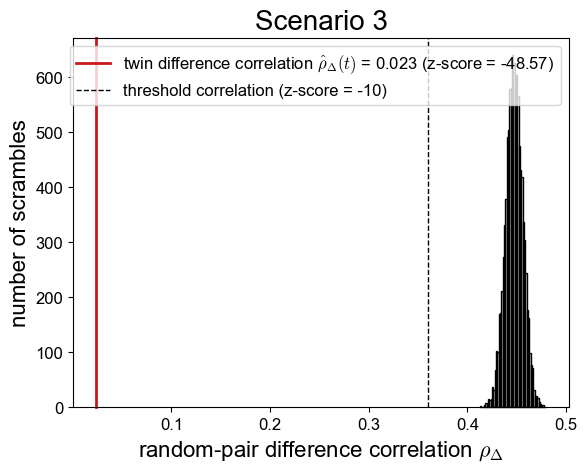

In [83]:
# csv_path_1  = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_high_k_on/df_rows_3_3_09082025_201359_ncells_6000_A_B_high_k_on_rep_0.csv"
# csv_path_2  = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_low_k_on/df_rows_2_2_09082025_210256_ncells_6000_A_B_low_k_on_rep_0.csv"
# path_to_simulation_file = [csv_path_1, csv_path_2]
# simulation = split_and_merge_simulations(path_to_simulation_file)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/connectivity_matrix_A_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )
# twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#     )
# random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs
# gene_i, gene_j = all_pairs[0]
# t_corr = twin_pair_correlation_matrix_t1.loc[gene_i, gene_j]
# r_corr = get_correlations(random_pair_correlation_distribution, gene_i, gene_j)
# r_corr_std = np.std(r_corr)

# z_score = (t_corr - np.mean(r_corr)) / r_corr_std
# threshold_corr = -10*r_corr_std + np.mean(r_corr)
outname = f"twin_vs_random_corr_A_B_2_states"
# df_out = pd.DataFrame({"random_corr": r_corr})
# df_out["twin_corr"] = t_corr
# df_out["z_score"] = z_score
# df_out["threshold_corr"] = threshold_corr
# df_out.to_csv(
#         f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/{outname}.csv",
#         index=False
#     )





df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

r_corr = df_out["random_corr"].tolist()
t_corr = df_out["twin_corr"].iloc[0]
z_score = df_out["z_score"].iloc[0]
threshold_corr = df_out["threshold_corr"].iloc[0]


# --- Plot ---
fig, ax = plt.subplots()
# Histogram (fixed light grey)
hist_color = "#d9d9d9"
ax.hist(r_corr, bins=50, color=hist_color, edgecolor="black")
# Actual twin correlation line (choose one color)
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "red"   # or "blue" / "grey"
ax.axvline(
    t_corr, linestyle="-",
    color=line_colors[choice], linewidth=2,
    label=rf"twin difference correlation ${{\hat{{\rho}}}}_{{\Delta}} (t)$ = {t_corr:.3f} (z-score = {z_score:.2f})"
)

ax.axvline(
    threshold_corr, linestyle="--",
    color="black", linewidth=1,
    label=rf"threshold correlation (z-score = -10)"
)
# Labels
xlabel = ax.set_xlabel(rf"random-pair difference correlation $\rho_\Delta$", fontsize=16)
ylabel = ax.set_ylabel("number of scrambles", fontsize=16)
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.title("Scenario 3")
# Title with Z-score
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# --- Save figure ---

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


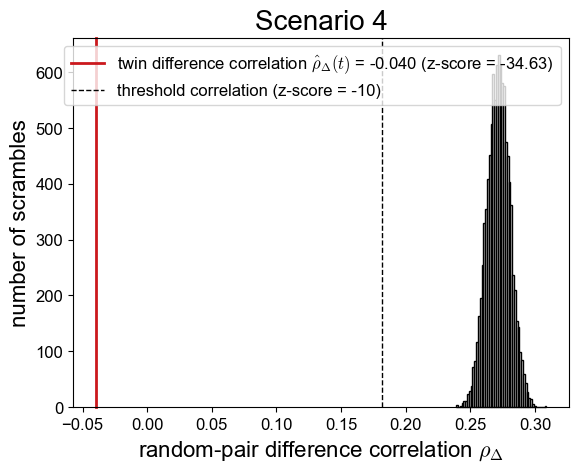

In [82]:
# csv_path_1  = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_0.csv"
# csv_path_2  = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_low_k_on/df_rows_2_2_09082025_212311_ncells_6000_A_to_B_low_k_on_rep_0.csv"
# path_to_simulation_file = [csv_path_1, csv_path_2]
# simulation = split_and_merge_simulations(path_to_simulation_file)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/interaction_matrix_A_to_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# np.random.seed(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )
# twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#     )
# random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs
# gene_i, gene_j = all_pairs[0]
# t_corr = twin_pair_correlation_matrix_t1.loc[gene_i, gene_j]
# r_corr = get_correlations(random_pair_correlation_distribution, gene_i, gene_j)
# r_corr_std = np.std(r_corr)

# z_score = (t_corr - np.mean(r_corr)) / r_corr_std
# threshold_corr = -10*r_corr_std + np.mean(r_corr)
outname = f"twin_vs_random_corr_A_to_B_2_states"
# df_out = pd.DataFrame({"random_corr": r_corr})
# df_out["twin_corr"] = t_corr
# df_out["z_score"] = z_score
# df_out["threshold_corr"] = threshold_corr
# df_out.to_csv(
#         f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/supp_figure/{outname}.csv",
#         index=False
#     )





df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")

r_corr = df_out["random_corr"].tolist()
t_corr = df_out["twin_corr"].iloc[0]
z_score = df_out["z_score"].iloc[0]
threshold_corr = df_out["threshold_corr"].iloc[0]


# --- Plot ---
fig, ax = plt.subplots()
# Histogram (fixed light grey)
hist_color = "#d9d9d9"
ax.hist(r_corr, bins=50, color=hist_color, edgecolor="black")
# Actual twin correlation line (choose one color)
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "red"   # or "blue" / "grey"
ax.axvline(
    t_corr, linestyle="-",
    color=line_colors[choice], linewidth=2,
    label=rf"twin difference correlation ${{\hat{{\rho}}}}_{{\Delta}} (t)$ = {t_corr:.3f} (z-score = {z_score:.2f})"
)

ax.axvline(
    threshold_corr, linestyle="--",
    color="black", linewidth=1,
    label=rf"threshold correlation (z-score = -10)"
)
# Labels
xlabel = ax.set_xlabel(rf"random-pair difference correlation $\rho_\Delta$", fontsize=16)
ylabel = ax.set_ylabel("number of scrambles", fontsize=16)
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.title("Scenario 4")
# Title with Z-score
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# --- Save figure ---

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.show()

## Directional correlations

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


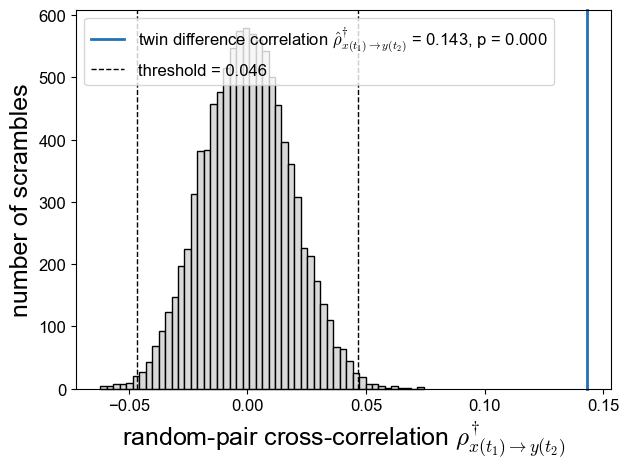

In [13]:
# path_to_simulation_file = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B/df_rows_0_1_05082025_160041_ncells_6000_A_to_B_rep_0.csv"
# simulation = pd.read_csv(path_to_simulation_file)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/interaction_matrix_A_to_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# rng = np.random.default_rng(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )
# twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#     )
# random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
# all_pairs = list(combinations(gene_list, 2))  # Unique undirected pairs
# import matplotlib as mpl
# import pandas as pd
# mpl.rcParams['svg.fonttype'] = 'none'   # keep text editable in SVG

# direction_raw_matrix, direction_normalized_matrix = get_cross_correlations(
#         across_t_twin1, across_t_twin2, gene_pairs=all_pairs
#     )
# g1, g2 = all_pairs[0]

# raw_val = direction_raw_matrix.loc[g1, g2]
# norm_val = direction_normalized_matrix.loc[g1, g2]
# # Shuffle test on raw values
# n_shuffles = 10000
# x = across_t_twin1[f"{g1}_mRNA"].values
# y = across_t_twin2[f"{g2}_mRNA"].values
# shuffles = np.array([rng.permutation(y) for _ in range(n_shuffles)])
    
# # Compute Spearman correlation for each shuffle
# shuffled_corrs = np.array([fast_corr(x, yy) for yy in shuffles])
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# # --- Settings ---
# percentile_threshold = 99
# hist_color = "#d9d9d9"  # fixed histogram color
# line_colors = {
#     "blue":  "#2171b5",
#     "red":   "#cb181d",
#     "grey":  "#525252",
# }
# choice = "blue"  # or "red", "grey"

# # Compute threshold from shuffled distribution
# current_threshold = np.percentile(np.abs(shuffled_corrs), percentile_threshold)

# # Empirical p-value
# p_value = np.mean(np.abs(shuffled_corrs) >= abs(raw_val))
# --- Save CSV with shuffle + actual values ---
outname = f"direction_A_to_B"
# df_out = pd.DataFrame({"shuffled_corrs": shuffled_corrs})
# df_out["actual_corr"] = raw_val
# df_out["normalized_corr"] = norm_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value
# df_out.to_csv(
#     f"{path_to_data}/{outname}.csv",
#     index=False
# )

df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")
raw_val = df_out["actual_corr"][0]
shuffled_corrs = df_out["shuffled_corrs"].to_list()
p_value = df_out["p_value"][0]
current_threshold = df_out["threshold"][0]
# --- Plot ---
plt.figure()
choice = "blue"
# Histogram of shuffled correlations
# Actual correlation line (colored)

plt.axvline(
    raw_val,
    color=line_colors[choice], linewidth=2, linestyle = "-",
    label="twin difference correlation " + rf"$\hat{{\rho}}^{{\dagger}}_{{x(t_{1}) \to y(t_{2})}}$ = {raw_val:.3f}, p = {p_value:.3f}"
)
plt.hist(shuffled_corrs, bins=50, color=hist_color, edgecolor="black")

# Threshold lines (±current_threshold, dashed black)
plt.axvline(
    current_threshold, linestyle="--", color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
plt.axvline(-current_threshold, linestyle="--", color="black", linewidth=1)



# Labels
xlabel = plt.xlabel("random-pair cross-correlation " + r"$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$")
ylabel = plt.ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)


plt.legend()

ax = plt.gca()   # get current axes

for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

# --- Save figure ---
plt.tight_layout()

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True, dpi = 600
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


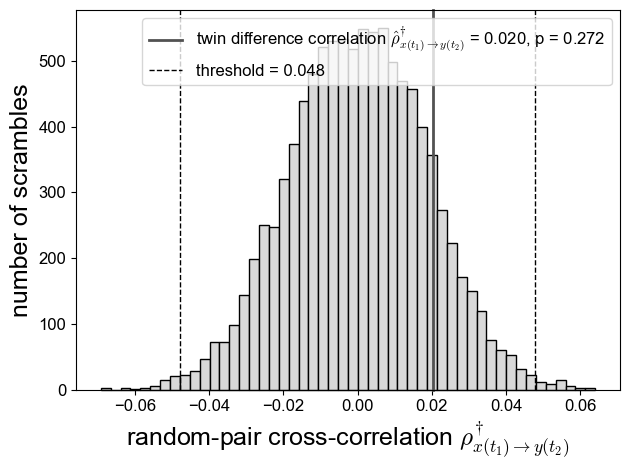

In [18]:
# path_to_simulation_file = "/home/keerthm/twinfer/df_rows_0_1_05082025_160158_ncells_6000_A_to_B_rep_1.csv"
# simulation = pd.read_csv(path_to_simulation_file)
# path_to_connectivity_matrix = f"/home/keerthm/twinfer/matrix.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 10110
# rng = np.random.default_rng(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )
# twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#     )
# random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
# all_pairs = list(permutations(gene_list, 2))  # Unique undirected pairs
# import matplotlib as mpl
# import pandas as pd
# mpl.rcParams['svg.fonttype'] = 'none'   # keep text editable in SVG

# direction_raw_matrix, direction_normalized_matrix = get_cross_correlations(
#         across_t_twin1, across_t_twin2, gene_pairs=all_pairs
#     )
# g1, g2 = all_pairs[0]

# raw_val = direction_raw_matrix.loc[g2, g1]
# norm_val = direction_normalized_matrix.loc[g2, g1]
# # Shuffle test on raw values
# n_shuffles = 10000
# x = across_t_twin2[f"{g1}_mRNA"].values
# y = across_t_twin1[f"{g2}_mRNA"].values
# shuffles = np.array([rng.permutation(y) for _ in range(n_shuffles)])
    
# # Compute Spearman correlation for each shuffle
# shuffled_corrs = np.array([fast_corr(x, yy) for yy in shuffles])
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# # --- Settings ---
# percentile_threshold = 99
# hist_color = "#d9d9d9"  # fixed histogram color
# line_colors = {
#     "blue":  "#2171b5",
#     "red":   "#cb181d",
#     "grey":  "#525252",
# }
# choice = "grey"  # or "red", "grey"

# # Compute threshold from shuffled distribution
# current_threshold = np.percentile(np.abs(shuffled_corrs), percentile_threshold)

# # Empirical p-value
# p_value = np.mean(np.abs(shuffled_corrs) >= abs(raw_val))

# --- Save CSV with shuffle + actual values ---
# df_out = pd.DataFrame({"shuffled_corrs": shuffled_corrs})
# outname = f"direction_B_to_A"
# df_out["actual_corr"] = raw_val
# df_out["normalized_corr"] = norm_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value
# df_out.to_csv(
#     f"{path_to_data}/{outname}.csv",
#     index=False
# )

df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")
raw_val = df_out["actual_corr"][0]
norm_val = df_out["normalized_corr"][0]
current_threshold = df_out["threshold"][0]
p_value = df_out["p_value"][0]
shuffled_corrs = df_out['shuffled_corrs'].to_list()
# --- Plot ---
fig, ax = plt.subplots()

# Histogram of shuffled correlations
ax.hist(shuffled_corrs, bins=50, color=hist_color, edgecolor="black")

# Actual correlation line (colored)
choice = "grey"
ax.axvline(
    raw_val,
    color=line_colors[choice], linewidth=2, linestyle = "-",
    label="twin difference correlation " + rf"$\hat{{\rho}}^{{\dagger}}_{{x(t_{1}) \to y(t_{2})}}$ = {raw_val:.3f}, p = {p_value:.3f}"
)

# Threshold lines (±current_threshold, dashed black)
ax.axvline(
    current_threshold, linestyle="--", color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
ax.axvline(-current_threshold, linestyle="--", color="black", linewidth=1)



# Labels
xlabel = ax.set_xlabel("random-pair cross-correlation " + r"$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$")
ylabel = ax.set_ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)


ax.legend()

# Remove clipping for all artists
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

# --- Save figure ---
plt.tight_layout()

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg", facecolor = "none", edgecolor = "none",
    transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png", facecolor = "none", edgecolor = "none",
    transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf", facecolor = "none", edgecolor = "none",
    transparent = True
)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


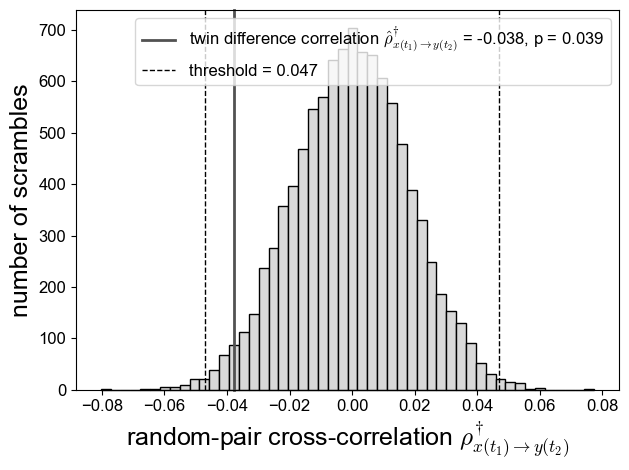

In [19]:
# path_to_simulation_file = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_3_simulations/A_rep_B/df_rows_6_6_22082025_150451_ncells_6000_A_represses_B_rep_0_b0755906.csv"
# simulation = pd.read_csv(path_to_simulation_file)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/interaction_matrix_A_to_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# rng = np.random.default_rng(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )
# twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#     )
# random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
# all_pairs = list(permutations(gene_list, 2))  # Unique undirected pairs
# import matplotlib as mpl
# import pandas as pd
# mpl.rcParams['svg.fonttype'] = 'none'   # keep text editable in SVG

# direction_raw_matrix, direction_normalized_matrix = get_cross_correlations(
#         across_t_twin1, across_t_twin2, gene_pairs=all_pairs
#     )
# g1, g2 = all_pairs[0]

# raw_val = direction_raw_matrix.loc[g2, g1]
# norm_val = direction_normalized_matrix.loc[g2, g1]
# # Shuffle test on raw values
# n_shuffles = 10000
# x = across_t_twin2[f"{g1}_mRNA"].values
# y = across_t_twin1[f"{g2}_mRNA"].values
# shuffles = np.array([rng.permutation(y) for _ in range(n_shuffles)])
    
# # Compute Spearman correlation for each shuffle
# shuffled_corrs = np.array([fast_corr(x, yy) for yy in shuffles])
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# # --- Settings ---
# percentile_threshold = 99
# hist_color = "#d9d9d9"  # fixed histogram color
# line_colors = {
#     "blue":  "#2171b5",
#     "red":   "#cb181d",
#     "grey":  "#525252",
# }
# choice = "grey"  # or "red", "grey"

# # Compute threshold from shuffled distribution
# current_threshold = np.percentile(np.abs(shuffled_corrs), percentile_threshold)

# # Empirical p-value
# p_value = np.mean(np.abs(shuffled_corrs) >= abs(raw_val))
outname = f"direction_B_rep_A"
# df_out = pd.DataFrame({"shuffled_corrs": shuffled_corrs})
# df_out["actual_corr"] = raw_val
# df_out["normalized_corr"] = norm_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value
# df_out.to_csv(
#     f"{path_to_data}/{outname}.csv",
#     index=False
# )

df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")
raw_val = df_out["actual_corr"][0]
shuffled_corrs = df_out["shuffled_corrs"].to_list()
p_value = df_out["p_value"][0]
current_threshold = df_out["threshold"][0]
# --- Plot ---
fig, ax = plt.subplots()
choice = "grey"
# Histogram of shuffled correlations
# Actual correlation line (colored)
ax.axvline(
    raw_val,
    color=line_colors[choice], linewidth=2, linestyle = "-",
    label=rf"twin difference correlation $\hat{{\rho}}^{{\dagger}}_{{x(t_{1}) \to y(t_{2})}}$ = {raw_val:.3f}, p = {p_value:.3f}"
)
ax.hist(shuffled_corrs, bins=50, color=hist_color, edgecolor="black")

# Threshold lines (±current_threshold, dashed black)
ax.axvline(
    current_threshold, linestyle="--", color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
ax.axvline(-current_threshold, linestyle="--", color="black", linewidth=1)



# Labels
xlabel = ax.set_xlabel("random-pair cross-correlation " + r"$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$")
ylabel = ax.set_ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)


ax.legend()

# Remove clipping for all artists
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

# --- Save figure ---
plt.tight_layout()
plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True, dpi = 600
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


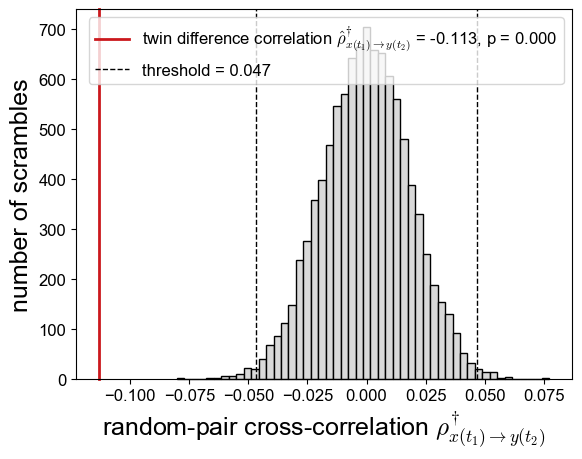

In [106]:
# path_to_simulation_file = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_3_simulations/A_rep_B/df_rows_6_6_22082025_150451_ncells_6000_A_represses_B_rep_0_b0755906.csv"
# simulation = pd.read_csv(path_to_simulation_file)
# path_to_connectivity_matrix = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/interaction_matrix_A_to_B.txt"
# n_clones_simulation = simulation['clone_id'].nunique()
# n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
# gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

# p_val_threshold = 0.01
# n_shuffles=10000

# # Shuffle clones
# seed = 101010
# rng = np.random.default_rng(seed)
# clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# n1 = n2 = n_clones_simulation // 4
# t1_clones = clone_ids_shuffled[:n1]
# t2_clones = clone_ids_shuffled[n1:n1 + n2]
# across_t_clones = clone_ids_shuffled[n1 + n2:]

# t1 = 1
# t2 = 20
# t1_twins = simulation[simulation['clone_id'].isin(t1_clones) & (simulation['time_step'] == t1)]

# t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# # Across_t: pick exactly one random twin per clone_id
# # One cell per clone at t1
# across_t_twin1 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation['replicate'] == 1)]
# )

# across_t_twin2 = (
#     simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2) & (simulation['replicate'] == 2)]
# )
# # Reset index for cleanliness
# t1_twins = t1_twins.reset_index(drop=True)
# t2_twins = t2_twins.reset_index(drop=True)
# across_t_twin1 = across_t_twin1.reset_index(drop=True)
# across_t_twin2 = across_t_twin2.reset_index(drop=True)
# all_t1_t2_measurements = pd.concat(
# [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
# ignore_index=True
# )
# twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
#         all_t1_t2_measurements, t1_twins, gene_list
#     )
# random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
# all_pairs = list(permutations(gene_list, 2))  # Unique undirected pairs
# import matplotlib as mpl
# import pandas as pd
# mpl.rcParams['svg.fonttype'] = 'none'   # keep text editable in SVG

# direction_raw_matrix, direction_normalized_matrix = get_cross_correlations(
#         across_t_twin1, across_t_twin2, gene_pairs=all_pairs
#     )
# g1, g2 = all_pairs[0]

# raw_val = direction_raw_matrix.loc[g1, g2]
# norm_val = direction_normalized_matrix.loc[g1, g2]
# # Shuffle test on raw values
# n_shuffles = 10000
# x = across_t_twin2[f"{g1}_mRNA"].values
# y = across_t_twin1[f"{g2}_mRNA"].values
# shuffles = np.array([rng.permutation(y) for _ in range(n_shuffles)])
    
# # Compute Spearman correlation for each shuffle
# shuffled_corrs = np.array([fast_corr(x, yy) for yy in shuffles])
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# # --- Settings ---
# percentile_threshold = 99
# hist_color = "#d9d9d9"  # fixed histogram color
# line_colors = {
#     "blue":  "#2171b5",
#     "red":   "#cb181d",
#     "grey":  "#525252",
# }
# choice = "red"  # or "red", "grey"

# # Compute threshold from shuffled distribution
# current_threshold = np.percentile(np.abs(shuffled_corrs), percentile_threshold)

# # Empirical p-value
# p_value = np.mean(np.abs(shuffled_corrs) >= abs(raw_val))

outname = f"direction_A_rep_B"
# df_out = pd.DataFrame({"shuffled_corrs": shuffled_corrs})
# df_out["actual_corr"] = raw_val
# df_out["normalized_corr"] = norm_val
# df_out["threshold"] = current_threshold
# df_out["p_value"] = p_value
# df_out.to_csv(
#     f"{path_to_data}/{outname}.csv",
#     index=False
# )

df_out = pd.read_csv(f"{path_to_data}/{outname}.csv")
raw_val = df_out["actual_corr"][0]
shuffled_corrs = df_out["shuffled_corrs"].to_list()
p_value = df_out["p_value"][0]
current_threshold = df_out["threshold"][0]
# --- Plot ---
fig, ax = plt.subplots()
choice = "red"
# Histogram of shuffled correlations
# Actual correlation line (colored)
ax.axvline(
    raw_val,
    color=line_colors[choice], linewidth=2, linestyle = "-",
    label=rf"twin difference correlation $\hat{{\rho}}^{{\dagger}}_{{x(t_{1}) \to y(t_{2})}}$ = {raw_val:.3f}, p = {p_value:.3f}"
)
ax.hist(shuffled_corrs, bins=50, color=hist_color, edgecolor="black")

# Threshold lines (±current_threshold, dashed black)
ax.axvline(
    current_threshold, linestyle="--", color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
ax.axvline(-current_threshold, linestyle="--", color="black", linewidth=1)



# Labels
xlabel = ax.set_xlabel("random-pair cross-correlation " + r"$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$")
ylabel = ax.set_ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)


ax.legend()

# Remove clipping for all artists
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

# --- Save figure ---

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True, dpi = 600
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.show()